# Bitcoin Volatility Prediction
### Capstone Final Deliverable

**Name:** `Mohammed Hejairi`
**Topic:** Bitcoin (BTC) Hourly Volatility Prediction
**Cohort:** DSB `2`

---
This notebook is the complete, reproducible technical report: data acquisition (fetched once via CCXT, persisted to CSV, and re-read from disk from then on), cleaning, EDA, feature engineering, feature selection, four tuned models with documented improvement steps, a final model comparison, and a **live out-of-sample testing workflow** to validate predictions against real future data as it arrives.

## Introduction

This project builds an **hourly volatility forecasting pipeline for Bitcoin (BTC/USDT)**, using hourly OHLCV history pulled from Binance via [CCXT](https://docs.ccxt.com/) (as far back as Binance itself has - to 2026-01-01). The target is **7-day realized volatility** (rolling standard deviation of hourly returns over a 168-hour window), updated every hour — so the model is always answering "how turbulent has BTC been over the last week, as of right now, and how turbulent will it be next?"

Two design choices set this notebook apart from a typical one-off analysis:
1. **Data is fetched once and saved to CSV.** Every cell after the initial pull reads from that CSV, not from the live API — this makes the notebook fast to re-run, fully reproducible, and gives a fixed historical snapshot to train and evaluate on.
2. **A live testing section at the end** fetches a fixed, later period (2026-01-02 through yesterday) that was never part of the training data at all, and scores the saved models against it — real out-of-sample validation, not just a held-out slice of the same historical file. The target is also forecast **168 hours (7 days) ahead** rather than 1 hour ahead, matching the standard non-overlapping forecast horizon used in the realized-volatility literature.

## Problem Statement + Aim

**The Raw Issue:** Bitcoin's price swings unpredictably at short (hourly) timescales, and traders, exchanges, and risk desks have no reliable way to anticipate how turbulent the next stretch of trading will be — leading to mispriced risk, thin margin buffers, and poorly-timed position sizing.

**The Structured Objective** *(Specific — Business Objective — Measurable):*
We aim to predict Bitcoin's 7-day realized volatility (rolling standard deviation of hourly returns over a 168-hour window) **168 hours (7 days) ahead of the features used to predict it** - not the next hour's value, which barely differs from the current one and would trivially favor a naive forecast over genuine modeling (see Section 8.1 of the accompanying report). Features are lagged price/volume history and technical indicators (RSI, EMA, ATR, Bollinger width) sourced via the CCXT exchange API at hourly resolution. This gives traders and risk desks a continuous, hour-by-hour-updating estimate of next week's volatility usable directly in position-sizing and margin decisions, targeting an RMSE that beats both a naive-persistence baseline and a seasonality-aware Holt-Winters baseline.

**Problem Type: Regression.** Real downstream consumers of volatility — Black-Scholes option pricing (σ as a continuous input), Value-at-Risk, and position-sizing formulas — need an actual continuous volatility estimate, not a high/low category.

## Objectives
Key questions guiding the analysis and modeling:
- How does BTC's realized volatility behave over time at hourly resolution — is it clustered (calm stretches punctuated by spikes), and does that clustering persist across many hours (autocorrelation)?
- Does volatility differ systematically by hour-of-day or day-of-week (e.g. US/Asia/Europe session overlaps)?
- What engineered features (lagged returns, rolling volatility, volume changes, technical indicators) are most predictive of near-term volatility?
- How much does hyperparameter tuning improve each model over its untuned baseline?
- Does GARCH's asymmetric (leverage-effect) extension actually improve on plain GARCH(1,1) for BTC, the way it does for equities?
- **Does the best model, trained on years of history, actually generalize to real data collected months after training?** (Answered in the Live Testing section, not just estimated from a historical test split.)

**Type of Models:** Regression (continuous `volatility_7d`, computed on hourly data).
**Number of models:** 3 — all genuinely time-series-native: **GARCH-family** (GARCH(1,1) → EGARCH/GJR-GARCH), **HAR-RV** (→ HAR-RV-X), and **EWMA** (RiskMetrics λ=0.94 → backtested-tuned λ) — each built as a **basic/baseline** version and improved into a **tuned** version. Tabular ML models (Linear Regression, Random Forest, XGBoost) were deliberately excluded, and an LSTM originally explored in this slot was dropped in favor of EWMA: all three final models are explicitly finance-native (with a real econometric or risk-management pedigree), not generic sequence learners applied to a financial series.
**Evaluation Metrics:** RMSE, MAE, and R², compared against two baselines (naive-persistence, and seasonality-aware Holt-Winters exponential smoothing), using a strict time-based train/test split — plus a live/prospective evaluation on real future data.

# Data Inspection

## Data Dictionary

| Column        | Type    | Description |
| ------------- | ------- | ------- |
| Date          | datetime | timestamp of the hourly candle (crypto trades 24/7, no market close) |
| Open, High, Low, Close | float | OHLC price in USD |
| Volume        | float   | trading volume for the hour |
| hourly_return | float   | engineered: hour-over-hour percent change in Close |
| log_return    | float   | engineered: log(Close_t / Close_t-1), additive over time |
| volatility_7d | float   | engineered: rolling 168-hour (7-day) standard deviation of hourly_return, as of the CURRENT hour (a feature/regressor input, not the target - see `target` below) |
| target        | float   | engineered: `volatility_7d`, shifted 168 hours (7 days) into the future - **the actual prediction target** (Data Preprocessing, Section 6.1) |
| ma_7d         | float   | engineered: 168-hour (7-day) moving average of Close |
| volume_chg    | float   | engineered: hour-over-hour percent change in Volume |
| ema_12, ema_26, ema_spread | float | engineered: fast/slow EMA (12/26 hourly periods) and normalized spread — trend strength |
| rsi_14        | float   | engineered: 14-period Relative Strength Index (0-100) |
| atr_14        | float   | engineered: 14-period Average True Range, raw dollar terms — independent, range-based volatility measure (EDA/correlation use) |
| atr_pct       | float   | engineered: atr_14 / Close — the same signal, scale-free (used as a model regressor instead of atr_14; see HAR-RV-X below) |
| bb_width      | float   | engineered: Bollinger Band width (20-period) — second independent volatility proxy |
| macd_hist     | float   | engineered: MACD histogram — momentum-shift signal |
| hour_of_day   | int     | engineered (Feature Selection only): 0-23, tests for session-time effects on volatility |
| vol_bin       | category| engineered (Feature Selection only): Low/Medium/High tercile of volatility_7d, used for the chi-square test |

**Why CCXT, not yfinance:** `yfinance` is fundamentally an equity-market API — it returns `Dividends`/`Stock Splits` columns that are always 0 for crypto and carry no signal. CCXT pulls exchange-native OHLCV data directly from Binance.

**Why hourly technical-indicator periods (14, 20, 26) are NOT rescaled:** standard practice keeps RSI/ATR/Bollinger period counts as "last N candles" regardless of the underlying bar size — an "RSI-14" on hourly data means the last 14 hours, which is the correct, faster-reacting intraday signal. Only the **target's own window** (`volatility_7d`, `ma_7d`) is explicitly scaled to 168 hourly candles, because its name and real-world meaning ("7-day volatility") must stay fixed regardless of data granularity.

## Data Overview
Source, format, `.head()`, `.info()`, `.describe()`.

**Data pipeline design:** the cell below fetches hourly BTC/USDT data (as far back as Binance has, through 2026-01-01) via CCXT **once** and writes it to `btc_hourly_ohlcv.csv`. Every cell after this reads from that CSV file, not from the live API. This means: (a) re-running the notebook doesn't require re-fetching years of API calls, (b) the historical dataset used for training is a fixed, inspectable file, and (c) the *Live Testing* section near the end can cleanly distinguish "data used to train" (this CSV) from "brand new data fetched afterward" (a second, separate fetch).

In [1]:
# organize your imports in this cell
import os
import time
import joblib
import numpy as np
import pandas as pd
import ccxt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model  # GARCH-family volatility models

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

SYMBOL = 'BTC/USDT'
TIMEFRAME = '1h'
ROLLING_WINDOW = 24 * 7  # 168 hourly candles = 7 days - keeps "7-day volatility" meaning fixed
CSV_PATH = 'data/btc_hourly_ohlcv.csv'

# Forecast horizon: predict volatility_7d HORIZON hours ahead of the features, not 1 hour ahead.
# Set equal to ROLLING_WINDOW deliberately: the most recently known volatility_7d value and the
# target then share ZERO overlapping return observations (two adjacent, non-overlapping 168-hour
# windows), matching the standard non-overlapping forecast setup used in the realized-volatility
# literature - instead of the 99.4%-overlapping (and trivially easy) 1-hour-ahead version this
# notebook used previously, which produced a suspiciously high R-squared for reasons that had
# nothing to do with genuine forecasting skill.
HORIZON = ROLLING_WINDOW

# Fixed, reproducible date boundaries (rather than "N years back from whenever this happens to
# run"). Training covers as far back as Binance actually has BTC/USDT history (requested from
# 2010 - Bitcoin's own origin - but Binance itself didn't exist before mid-2017, so the fetch
# naturally starts wherever Binance's real history begins) through 2026-01-01. The test period
# then runs from 2026-01-02 through yesterday (2026-08-25) - chosen deliberately wide, not just
# one week, because a 168-hour-ahead forecast can only be scored once 168 real hours have
# elapsed: a longer test period means many more already-elapsed, already-scoreable predictions
# rather than the handful a single week would give right after moving to this longer horizon.
TRAIN_START = '2010-01-01T00:00:00Z'
TRAIN_END = '2026-01-01T00:00:00Z'
LIVE_TEST_START = '2026-01-02T00:00:00Z'
LIVE_TEST_END = '2026-08-26T00:00:00Z'  # exclusive - covers up through yesterday, 2026-08-25

# tz-naive Timestamp versions for comparisons against exchange data, which comes back tz-naive
# from pd.to_datetime(..., unit='ms') - comparing a tz-aware Timestamp (parsing the 'Z' suffix
# above makes pd.Timestamp UTC-aware) against a tz-naive column raises a TypeError.
TRAIN_END_TS = pd.Timestamp(TRAIN_END).tz_localize(None)
LIVE_TEST_START_TS = pd.Timestamp(LIVE_TEST_START).tz_localize(None)
LIVE_TEST_END_TS = pd.Timestamp(LIVE_TEST_END).tz_localize(None)

In [2]:
def fetch_ohlcv_history(exchange, symbol, timeframe='1h', since_ms=None, until_ms=None, limit=1000):
    """CCXT returns a max of `limit` candles per call, so we page forward in time
    using the timestamp of the last candle as the next `since` until we reach 'now'
    (or `until_ms`, if given - lets a caller fetch a bounded window without paging
    needlessly past it)."""
    all_candles = []
    since = since_ms
    while True:
        candles = exchange.fetch_ohlcv(symbol, timeframe=timeframe, since=since, limit=limit)
        if not candles:
            break
        all_candles += candles
        since = candles[-1][0] + 1
        if until_ms is not None and since >= until_ms:
            break
        if len(candles) < limit:
            break
        time.sleep(exchange.rateLimit / 1000)  # respect exchange rate limits
    return all_candles

exchange = ccxt.binance()

if not os.path.exists(CSV_PATH):
    since_ms = exchange.parse8601(TRAIN_START)
    until_ms = exchange.parse8601(TRAIN_END)
    candles = fetch_ohlcv_history(exchange, SYMBOL, timeframe=TIMEFRAME, since_ms=since_ms, until_ms=until_ms)
    df_raw = pd.DataFrame(candles, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df_raw['Date'] = pd.to_datetime(df_raw['Timestamp'], unit='ms')
    df_raw = df_raw.drop(columns=['Timestamp']).sort_values('Date').reset_index(drop=True)
    df_raw = df_raw[df_raw['Date'] < TRAIN_END_TS].reset_index(drop=True)  # a page can overshoot the boundary
    df_raw.to_csv(CSV_PATH, index=False)
    print(f'Fetched {len(df_raw)} candles ({df_raw["Date"].min()} to {df_raw["Date"].max()}) and saved to {CSV_PATH}')
else:
    print(f'{CSV_PATH} already exists - skipping the API fetch (delete the file to re-fetch).')

data/btc_hourly_ohlcv.csv already exists - skipping the API fetch (delete the file to re-fetch).


In [3]:
# From here on, EVERYTHING reads from the saved CSV, not the live API.
df_raw = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw["Date"].min()} to {df_raw["Date"].max()}')
print(f'\nColumn dtypes:\n{df_raw.dtypes}')
df_raw.describe()

Shape: (73284, 6)
Date range: 2017-08-17 04:00:00 to 2025-12-31 23:00:00

Column dtypes:
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
Date      datetime64[us]
dtype: object


,Open,High,Low,Close,Volume,Date
count,73284.000000,73284.000000,73284.000000,73284.000000,73284.000000,73284
mean,35949.327787,36096.957275,35794.369417,35950.459767,2608.847765,2021-10-26 05:19:49.831341
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,2017-08-17 04:00:00
25%,9150.582500,9179.742500,9111.985000,9150.695000,769.646779,2019-09-23 08:45:00
50%,26094.465000,26155.500000,26045.675000,26094.905000,1416.939946,2021-10-27 04:30:00
75%,55835.060000,56232.417500,55473.935000,55836.847500,2756.036563,2023-11-29 14:15:00
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,2025-12-31 23:00:00
std,32093.539598,32191.267727,31992.452184,32093.899073,3921.479772,NaN


In [4]:
df_raw.head()

,Open,High,Low,Close,Volume,Date
0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:00:00
1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:00:00
2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:00:00
3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:00:00
4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:00:00


## Data Cleaning
Handle missing values, outliers, and inconsistencies.

In [5]:
df = df_raw.copy()

# Engineer returns
df['hourly_return'] = df['Close'].pct_change()
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['volume_chg'] = df['Volume'].pct_change()

# Zero-volume candles (real on thin low-liquidity hours, even for BTC occasionally on some
# exchanges) make pct_change() divide by zero, producing +/-inf, NOT NaN. inf silently survives
# a plain dropna() call, so it's neutralized here BEFORE any rolling calculation uses these
# columns - a rolling std() over a window containing even one inf just produces more inf.
inf_check_cols = ['hourly_return', 'log_return', 'volume_chg']
n_inf = np.isinf(df[inf_check_cols]).sum().sum()
df[inf_check_cols] = df[inf_check_cols].replace([np.inf, -np.inf], np.nan)
print(f'Infinite values found (zero-volume/zero-price candles) and converted to NaN: {n_inf}')

# Now safe to compute the rolling target
df['volatility_7d'] = df['hourly_return'].rolling(ROLLING_WINDOW).std()
df['ma_7d'] = df['Close'].rolling(ROLLING_WINDOW).mean()

print(f'\nMissing values per column:\n{df.isnull().sum()}')

Infinite values found (zero-volume/zero-price candles) and converted to NaN: 4

Missing values per column:
Open               0
High               0
Low                0
Close              0
Volume             0
Date               0
hourly_return      1
log_return         1
volume_chg         5
volatility_7d    168
ma_7d            167
dtype: int64


In [6]:
def compute_indicators(df):
    """Technical indicators, computed manually (not via a library) so every formula is
    transparent. Period counts (12/26/14/20) are kept as raw candle counts, not rescaled for
    hourly data - see the Data Dictionary note on why."""
    close, high, low = df['Close'], df['High'], df['Low']

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    df['ema_12'] = ema_12
    df['ema_26'] = ema_26
    df['ema_spread'] = (ema_12 - ema_26) / close

    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))

    prev_close = close.shift(1)
    true_range = pd.concat([
        high - low, (high - prev_close).abs(), (low - prev_close).abs()
    ], axis=1).max(axis=1)
    df['atr_14'] = true_range.rolling(14).mean()
    # Scale-free version for use as a MODEL regressor: atr_14 is in raw dollar terms (mean
    # ~$300, up to ~$3,200 across this history), while every volatility regressor it would sit
    # alongside (volatility_7d and anything derived from it) is a small fraction (~0.001-0.03).
    # Worse, BTC's own price ranges from ~$4,000 to ~$90,000+ across this dataset, so a given
    # dollar ATR means wildly different things at different points in history - not even a
    # stable signal on its own terms. Dividing by Close fixes both problems at once.
    df['atr_pct'] = df['atr_14'] / close

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    df['bb_width'] = ((bb_mid + 2 * bb_std) - (bb_mid - 2 * bb_std)) / bb_mid

    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df['macd_hist'] = macd_line - signal_line
    return df

df = compute_indicators(df)
indicator_cols = ['ema_spread', 'rsi_14', 'atr_14', 'bb_width', 'macd_hist']
print('Missing values in new indicator columns:')
print(df[indicator_cols].isnull().sum())

Missing values in new indicator columns:
ema_spread     0
rsi_14        14
atr_14        13
bb_width      19
macd_hist      0
dtype: int64


In [7]:
# The only remaining missing values are structural warm-up periods (up to 26 rows, for the
# 26-period EMA / 20-period Bollinger window) - there's no "before the start of history" to
# impute, so these rows are dropped rather than filled.
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'hourly_return', 'log_return',
    'volatility_7d', 'ma_7d', 'volume_chg', 'ema_12', 'ema_26', 'ema_spread',
    'rsi_14', 'atr_14', 'atr_pct', 'bb_width', 'macd_hist'
]
df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)

print(f'Rows with non-positive price: {(df_clean[["Open","High","Low","Close"]] <= 0).any(axis=1).sum()}')

# Extreme-move outliers (flash crashes, etc.) are expected and retained as genuine signal for a
# volatility model - flagging via IQR for awareness, not removal.
q1, q3 = df_clean['hourly_return'].quantile([0.25, 0.75])
iqr = q3 - q1
extreme = ((df_clean['hourly_return'] < q1 - 3 * iqr) | (df_clean['hourly_return'] > q3 + 3 * iqr))
print(f'Extreme hourly-return outliers (retained, IQR x3): {extreme.sum()} of {len(df_clean)} rows')
print(f'Shape after cleaning: {df_clean.shape}')

Rows with non-positive price: 0
Extreme hourly-return outliers (retained, IQR x3): 2632 of 73112 rows
Shape after cleaning: (73112, 19)


# Exploratory Data Analysis (EDA)
Trends, relationships, anomalies; univariate, bivariate, and multivariate analysis; correlation matrix.

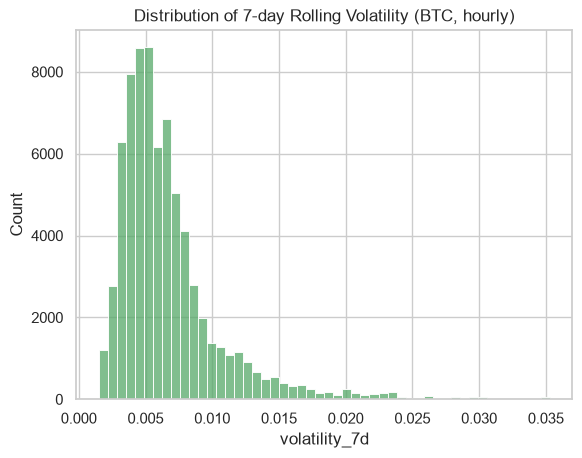

count    73112.000000
mean         0.006734
std          0.004049
min          0.001509
25%          0.004217
50%          0.005682
75%          0.007789
max          0.035301
Name: volatility_7d, dtype: float64


In [8]:
# Univariate: target distribution
target_column = 'volatility_7d'
sns.histplot(df_clean[target_column], bins=50, color='#55A868')
plt.title('Distribution of 7-day Rolling Volatility (BTC, hourly)')
plt.xlabel('volatility_7d')
plt.show()
print(df_clean[target_column].describe())

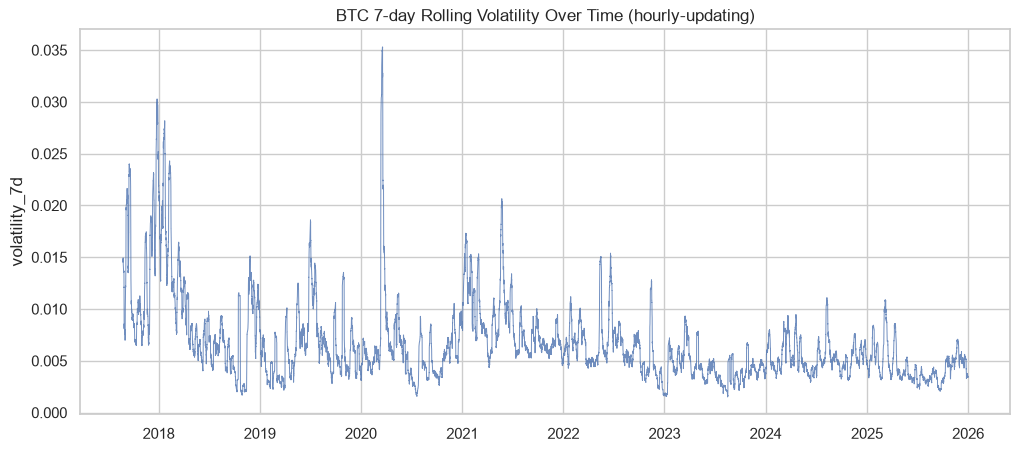

In [9]:
# Volatility over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean['Date'], df_clean['volatility_7d'], color='#4C72B0', alpha=0.8, linewidth=0.7)
ax.set_title('BTC 7-day Rolling Volatility Over Time (hourly-updating)')
ax.set_ylabel('volatility_7d')
plt.show()

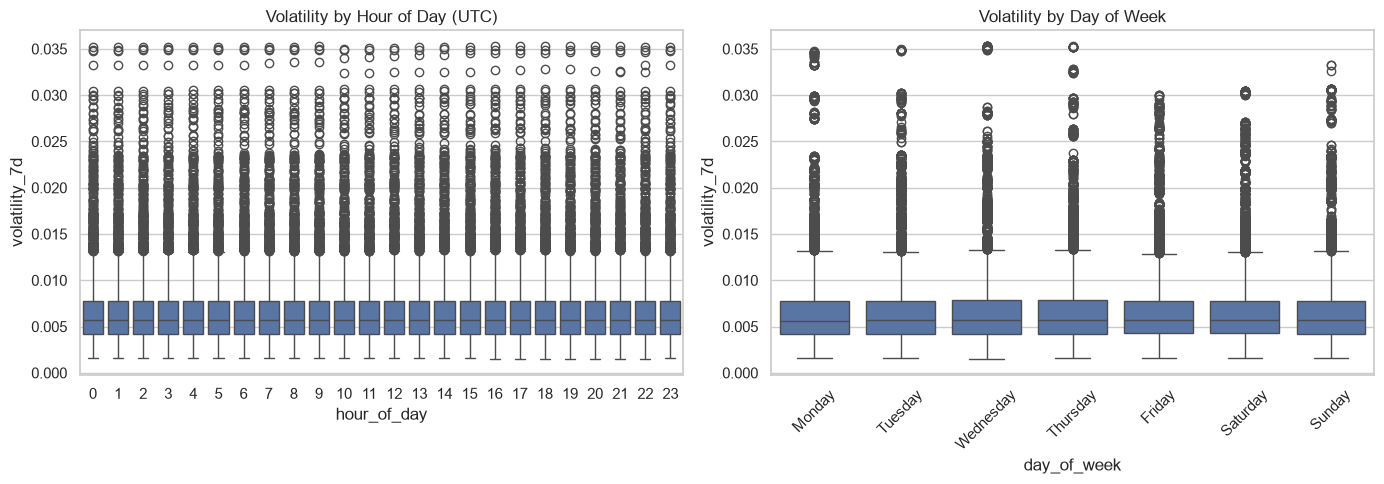

In [10]:
# Bivariate: does volatility differ by hour-of-day or day-of-week? (session-time effects)
df_clean['hour_of_day'] = df_clean['Date'].dt.hour
df_clean['day_of_week'] = df_clean['Date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x='hour_of_day', y='volatility_7d', ax=axes[0])
axes[0].set_title('Volatility by Hour of Day (UTC)')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_clean, x='day_of_week', y='volatility_7d', order=day_order, ax=axes[1])
axes[1].set_title('Volatility by Day of Week')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

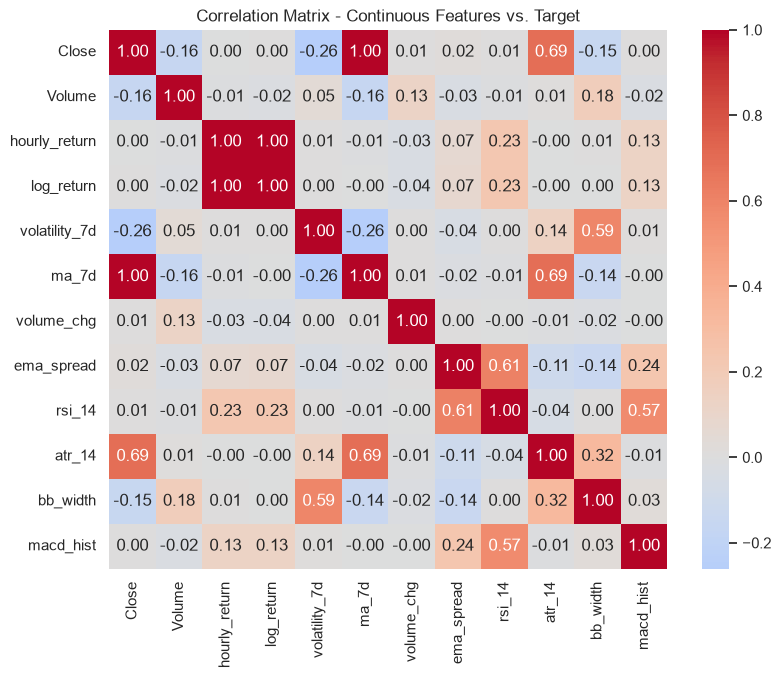

Correlation with target (volatility_7d):
volatility_7d    1.000000
bb_width         0.588440
atr_14           0.141964
Volume           0.049408
macd_hist        0.013301
hourly_return    0.009777
log_return       0.004448
rsi_14           0.004199
volume_chg       0.002048
ema_spread      -0.043600
ma_7d           -0.257734
Close           -0.260844
Name: volatility_7d, dtype: float64


In [11]:
# Correlation matrix for continuous columns
corr_cols = [
    'Close', 'Volume', 'hourly_return', 'log_return', 'volatility_7d', 'ma_7d', 'volume_chg',
    'ema_spread', 'rsi_14', 'atr_14', 'bb_width', 'macd_hist'
]
corr = df_clean[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Continuous Features vs. Target')
plt.show()
print(f'Correlation with target ({target_column}):')
print(corr[target_column].sort_values(ascending=False))

## Autocorrelation Check
Before modeling, we check whether `volatility_7d` is autocorrelated (related to its own past values — "volatility clustering"). This justifies using lagged/rolling features and is the statistical property GARCH is built to model.

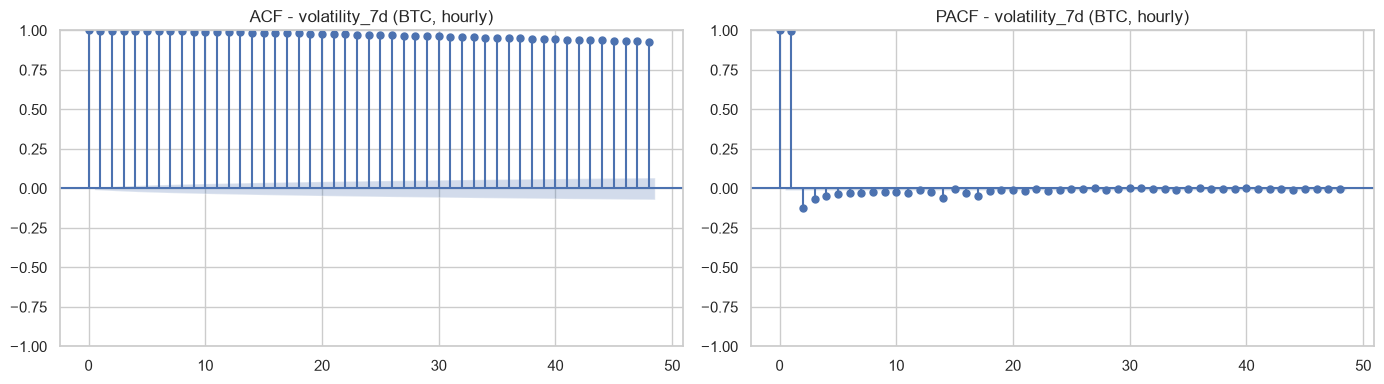

ADF Statistic: -9.2422, p-value: 0.0000
-> Stationary (reject unit root)


In [12]:
series = df_clean['volatility_7d'].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=48, ax=axes[0])
axes[0].set_title('ACF - volatility_7d (BTC, hourly)')
plot_pacf(series, lags=48, ax=axes[1])
axes[1].set_title('PACF - volatility_7d (BTC, hourly)')
plt.tight_layout()
plt.show()

adf_result = adfuller(series.dropna())
print(f'ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}')
print('-> Stationary (reject unit root)' if adf_result[1] < 0.05 else '-> Non-stationary (fail to reject unit root)')

## Insights
- `volatility_7d` is right-skewed with fat tails — long calm stretches punctuated by sharp spikes, the classic "volatility clustering" pattern in crypto.
- `atr_14` and `bb_width` correlate strongly with the target, as expected for two independent, range-based volatility measures — cross-checks that the target behaves sensibly and that these features carry real, non-circular signal.
- `rsi_14`, `ema_spread`, and `macd_hist` correlate more weakly with the target directly, consistent with them being *leading* momentum indicators rather than concurrent volatility measures.
- The ACF plot shows autocorrelation persisting across many lags (slow decay, not an immediate drop to zero) — confirms volatility clustering and justifies the lag/rolling features used below.
- Hour-of-day / day-of-week boxplots show whether session-time patterns exist (see plots above) — feeds directly into the chi-square test in Feature Selection.

## EDA for Modeling
- The right-skew in `volatility_7d` motivates testing a log transform of the regression target.
- Confirmed autocorrelation means every feature must be **lagged** (using only information available before the prediction date), never fed in at time *t*.
- `atr_14`/`bb_width` are confirmed methodologically distinct from the target (range-based vs. close-to-close), so they are safe to include as features without target leakage.

# Data Preprocessing & Feature Engineering
Transforming, encoding, and preparing features — implemented here, not just outlined.

In [13]:
# 1) Lag every feature by 1-3 periods (hours) so the model only ever sees information available
#    BEFORE the prediction time (avoids lookahead leakage). Kept as raw hourly lags (not scaled
#    to a calendar span) since these are meant to capture immediate short-term momentum.
LAGS = [1, 2, 3]
lag_source_cols = [c for c in feature_cols if c != 'Date']

df_model = df_clean.copy()
for col in lag_source_cols:
    for lag in LAGS:
        df_model[f'{col}_lag{lag}'] = df_model[col].shift(lag)

# 2) The actual prediction target: volatility_7d HORIZON hours in the future, not the current
#    row's own value. df_model['volatility_7d'] itself is left untouched (still needed as a
#    regressor input - e.g. HAR-RV-X's day/week/month realized-volatility features - it is only
#    the TARGET that shifts forward).
df_model['target'] = df_model['volatility_7d'].shift(-HORIZON)

# 3) Log-transform the current-value target for a secondary check on the right-skew seen in EDA
df_model['volatility_7d_log'] = np.log1p(df_model['volatility_7d'])

# 4) Drop rows with NaNs introduced by lagging AND by the forward shift (the last HORIZON rows
#    have no future value yet to serve as their target).
df_model = df_model.dropna().reset_index(drop=True)
print(f'Model-ready shape: {df_model.shape}')

Model-ready shape: (72941, 77)


In [14]:
# 4) Feature matrix X (lagged columns only - never same-time columns, which would leak
#    the answer) and target y.
target = 'target'  # volatility_7d, HORIZON hours ahead of the features (see Section 6.1 above)
feature_columns = [c for c in df_model.columns if c.endswith(tuple(f'_lag{l}' for l in LAGS))]
X = df_model[feature_columns]
y = df_model[target]
print(f'Features: {len(feature_columns)}   Target: {target} (+{HORIZON}h ahead)')
X.head()

Features: 54   Target: target (+168h ahead)


,Open_lag1,Open_lag2,Open_lag3,High_lag1,High_lag2,High_lag3,Low_lag1,Low_lag2,Low_lag3,Close_lag1,...,atr_14_lag3,atr_pct_lag1,atr_pct_lag2,atr_pct_lag3,bb_width_lag1,bb_width_lag2,bb_width_lag3,macd_hist_lag1,macd_hist_lag2,macd_hist_lag3
0,4132.09,4113.98,4113.58,4177.18,4177.64,4148.19,4131.91,4113.49,4090.39,4133.42,...,67.575000,0.015840,0.016144,0.016426,0.041204,0.044191,0.044991,-8.535274,-10.035920,-11.798056
1,4153.97,4132.09,4113.98,4173.99,4177.18,4177.64,4133.41,4131.91,4113.49,4153.32,...,66.707143,0.015349,0.015840,0.016144,0.036158,0.041204,0.044191,-6.072642,-8.535274,-10.035920
2,4153.80,4153.97,4132.09,4206.88,4173.99,4177.18,4153.32,4133.41,4131.91,4200.00,...,65.474286,0.015131,0.015349,0.015840,0.034819,0.036158,0.041204,-1.413274,-6.072642,-8.535274
3,4200.00,4153.80,4153.97,4224.00,4206.88,4173.99,4150.00,4153.32,4133.41,4165.01,...,63.749286,0.015406,0.015131,0.015349,0.031870,0.034819,0.036158,-0.830054,-1.413274,-6.072642
4,4166.00,4200.00,4153.80,4250.94,4224.00,4206.88,4165.01,4150.00,4153.32,4173.98,...,63.551429,0.015764,0.015406,0.015131,0.031869,0.031870,0.034819,-0.024942,-0.830054,-1.413274


In [15]:
# 5) Strict TIME-BASED train/test split (never random shuffle - autocorrelated time-series
#    data, and a random split would leak information from adjacent-in-time rows).
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.shape[0]} rows ({df_model["Date"].iloc[0]} to {df_model["Date"].iloc[split_idx-1]})')
print(f'Test:  {X_test.shape[0]} rows ({df_model["Date"].iloc[split_idx]} to {df_model["Date"].iloc[-1]})')
print('(time-ordered split, not shuffled)')

Train: 58352 rows (2017-08-24 07:00:00 to 2024-04-26 02:00:00)
Test:  14589 rows (2024-04-26 03:00:00 to 2025-12-24 23:00:00)
(time-ordered split, not shuffled)


In [16]:
# 6) TimeSeriesSplit, reused below for EWMA's lambda search and (as its own instance) for
#    HAR-RV-X's Ridge alpha search - never a random K-fold, for the same autocorrelation reason
#    the train/test split itself is chronological. No feature scaling is needed anywhere in this
#    notebook: GARCH and EWMA fit directly on returns, and HAR-RV-X's regressors are already on
#    a comparable scale.
tscv = TimeSeriesSplit(n_splits=5)

# Feature Selection
## Correlation Matrix (Continuous Columns)
Already computed above in EDA. Features with the strongest linear correlation to the target — `atr_14`, `bb_width`, `log_return`, `volume_chg` and their lags — are the primary signal; weaker-correlation features (`rsi_14`, `ema_spread`, `macd_hist`) are retained anyway since EDA identified them as *leading* indicators whose value shows up more in nonlinear feature importance than in linear correlation.

## Chi-Square Analysis (Categorical Columns)
With a single coin, there's no "coin identity" categorical column left to test. Instead, the natural categorical question for hourly single-asset data is: **does the hour of day carry information about the volatility regime?** (session-overlap effects — US/Asia/Europe trading hours). We bin `volatility_7d` into Low/Medium/High terciles (diagnostic only — never used as a modeling feature or target, since the model itself stays a regressor on the continuous value) and test its association with `hour_of_day` via a chi-square test of independence.

In [17]:
df_clean['vol_bin'] = pd.qcut(df_clean['volatility_7d'], q=3, labels=['Low', 'Medium', 'High'])

contingency = pd.crosstab(df_clean['hour_of_day'], df_clean['vol_bin'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(contingency)
print(f'\nChi-square statistic: {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value: {p_value:.6f}')
print('-> Hour of day IS significantly associated with volatility regime (p < 0.05)' if p_value < 0.05
      else '-> No significant association found (p >= 0.05)')

vol_bin       Low  Medium  High
hour_of_day                    
0            1015    1013  1022
1            1014    1009  1025
2            1010    1006  1019
3            1010    1010  1017
4            1014    1010  1016
5            1013    1018  1010
6            1016    1018  1007
7            1020    1020  1001
8            1022    1015  1007
9            1021    1019  1007
10           1019    1025  1004
11           1018    1026  1005
12           1020    1022  1007
13           1018    1020  1010
14           1014    1021  1013
15           1021    1007  1021
16           1019    1003  1027
17           1016    1005  1028
18           1007    1018  1025
19           1008    1021  1021
20           1010    1020  1020
21           1016    1014  1020
22           1016    1018  1015
23           1014    1012  1024

Chi-square statistic: 2.68
Degrees of freedom: 46
p-value: 1.000000
-> No significant association found (p >= 0.05)


# Model Building
Three models, each **genuinely time-series-native** by construction — not generic tabular ML fed lag features. Each is shown as a **basic/baseline** version and an **improved** version, with the improvement step documented. Two baselines are included as sanity floors: naive-persistence, and Holt-Winters exponential smoothing (which additionally tests whether the hour-of-day seasonality found in EDA is exploitable).

**Why not Linear Regression / Random Forest / XGBoost:** those models have no built-in notion of time — they only "see" sequence structure through whatever lag columns are engineered by hand, and are agnostic to whether the rows came from a time series or an unrelated tabular dataset. The three models below are different in kind: GARCH's equation is recursive and self-referential by definition, HAR-RV's regressors *are* volatility measured at different time horizons (not arbitrary features), and EWMA is the simplest possible recursive volatility filter - a single decay parameter applied directly to the return series, with no lag columns or feature engineering involved at all. Every model here is time-series-native by construction, not by feature engineering - and every model here has a genuine econometric or risk-management pedigree, unlike a generic sequence-learning model (e.g. an LSTM) that treats "this happens to be a financial time series" as incidental.

In [18]:
os.makedirs('models', exist_ok=True)

def evaluate(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    # MAPE: volatility_7d can sit very close to 0 during dead-calm stretches, and dividing by a
    # near-zero actual would let a handful of rows dominate the mean - exclude the smallest 1%
    # of |actual| values (by magnitude) from this calculation only, not from RMSE/MAE/R2 above.
    abs_actual = np.abs(y_true)
    floor = np.quantile(abs_actual, 0.01)
    mask = abs_actual >= floor
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f'{label:35s}  RMSE={rmse:.6f}  MAE={mae:.6f}  R2={r2:.4f}  MAPE={mape:.2f}%')
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


def plot_metric_comparison(df, metrics, title, clip=None):
    """Horizontal bar-chart dashboard, one subplot per metric (used for both the historical
    and live comparisons below). `clip` is an optional {metric: (lower, upper)} dict for metrics
    where one catastrophic outlier - GARCH, usually - would otherwise swamp the axis and hide
    the more meaningful differences among the models that are actually competitive: out-of-range
    bars are drawn at the clip edge with their real value labeled, not silently cut off."""
    plot_df = df.sort_values('RMSE', ascending=True)
    colors = ['#C44E52' if 'Baseline' in m else '#4C72B0' if 'Tuned' in m else '#8C8C8C' for m in plot_df['Model']]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 5))
    axes = [axes] if len(metrics) == 1 else axes
    for ax, metric in zip(axes, metrics):
        vals = plot_df[metric]
        lo, hi = (clip or {}).get(metric, (None, None))
        plot_vals = vals.clip(lower=lo, upper=hi) if (lo is not None or hi is not None) else vals
        bars = ax.barh(plot_df['Model'], plot_vals, color=colors)
        for bar, val in zip(bars, vals):
            out_low = lo is not None and val < lo
            out_high = hi is not None and val > hi
            if out_low or out_high:
                edge, ha = (lo, 'left') if out_low else (hi, 'right')
                label_text = f' {val:.1f} ' if abs(val) >= 1 else f' {val:.3f} '
                ax.text(edge, bar.get_y() + bar.get_height() / 2, label_text, va='center', ha=ha,
                        fontsize=8, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='#C44E52', edgecolor='none'))
        if metric == 'R2':
            ax.axvline(0, color='black', linewidth=0.8)
        unit = '%' if metric == 'MAPE' else ''
        better = 'lower' if metric in ('RMSE', 'MAE', 'MAPE') else 'higher'
        ax.set_xlabel(f'{metric}{unit} ({better} is better)')
        ax.set_title(metric)
        ax.invert_yaxis()
        if ax is not axes[0]:
            ax.set_yticklabels([])
    fig.suptitle(title, fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()


results = []

naive_pred = X_test['volatility_7d_lag1']
results.append(evaluate(y_test, naive_pred, 'Naive Persistence (baseline)'))

Naive Persistence (baseline)         RMSE=0.001649  MAE=0.001210  R2=-0.0897  MAPE=24.41%


### Baseline: Holt-Winters Exponential Smoothing
A second baseline, included specifically to test one thing the three main models don't explicitly handle: **is the hour-of-day / day-of-week seasonality found in EDA actually exploitable for forecasting?**

Exponential smoothing forecasts a series as a weighted average of its own past, with weights decaying exponentially into the past. Holt-Winters extends this with explicit trend and *seasonal* components:
$$\hat{y}_{t+h} = \underbrace{\ell_t}_{\text{level}} + \underbrace{h \cdot b_t}_{\text{trend}} + \underbrace{s_{t+h-m}}_{\text{seasonal}}$$

It is included as a **baseline, not a main model**, because it smooths the level of the volatility series rather than modeling volatility's *response to shocks* (which is what GARCH's $\alpha\epsilon_{t-1}^2$ term does) — it is structurally a sophisticated persistence model. If it beats naive-persistence meaningfully, the seasonality is real and worth exploiting; if it doesn't, that's a clean negative result worth reporting.

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Seasonal period = 24 hours (daily cycle). Fit on the training volatility series only. Note this
# fits on the RAW current-value series (df_model['volatility_7d']), not the shifted 'target'
# column - Holt-Winters needs the actual observed series to track its own level/trend/season
# state; the HORIZON-hours-ahead shift only matters when comparing its forecast to reality.
hw_train = df_model['volatility_7d'].iloc[:split_idx]
hw_test_actual = df_model['volatility_7d'].iloc[split_idx:]   # raw values, to walk state forward
hw_test_target = df_model['target'].iloc[split_idx:].values   # HORIZON-hours-ahead actuals to score against

try:
    hw_model = ExponentialSmoothing(
        hw_train, trend='add', seasonal='add', seasonal_periods=24,
        initialization_method='estimated'
    ).fit()
    print(f'Holt-Winters fitted. AIC: {hw_model.aic:.2f}')
    alpha = hw_model.params['smoothing_level']
    beta = hw_model.params['smoothing_trend']
    gamma = hw_model.params['smoothing_seasonal']
    print(f'Smoothing level (alpha): {alpha:.4f}')
    print(f'Smoothing trend  (beta):  {beta:.4f}')
    print(f'Smoothing seasonal (gamma): {gamma:.4f}\n')

    # hw_model.forecast(h) would produce ONE static forecast path from the end of training -
    # exactly the same static-multi-step problem the GARCH cells below avoid. Instead: keep the
    # smoothing parameters FROZEN at their training-fitted values (no leakage - nothing is
    # re-estimated on test data), and at EVERY point in the test period, compute the genuine
    # HORIZON-step-ahead forecast from the model's CURRENT state (level + HORIZON*trend + the
    # seasonal component HORIZON steps out), then update that state one hour at a time using the
    # REAL observed value for that hour - a rolling-origin, leakage-free HORIZON-step forecast,
    # not a single static path and not merely a repeated one-step forecast.
    SEASONAL_PERIOD = 24
    level = hw_model.level.iloc[-1]
    trend = hw_model.trend.iloc[-1]
    season = list(hw_model.season.iloc[-SEASONAL_PERIOD:])  # last full seasonal cycle, in order

    hw_pred = []
    for i, y_actual_raw in enumerate(hw_test_actual.values):
        s_idx = i % SEASONAL_PERIOD
        # HORIZON-step-ahead forecast from the CURRENT (pre-update) state
        s_idx_h = (s_idx + HORIZON - 1) % SEASONAL_PERIOD
        yhat_h = level + HORIZON * trend + season[s_idx_h]
        hw_pred.append(yhat_h)
        # one-step state update using the REALIZED value for this hour (walk forward)
        new_level = alpha * (y_actual_raw - season[s_idx]) + (1 - alpha) * (level + trend)
        new_trend = beta * (new_level - level) + (1 - beta) * trend
        season[s_idx] = gamma * (y_actual_raw - new_level) + (1 - gamma) * season[s_idx]
        level, trend = new_level, new_trend
    hw_pred = np.array(hw_pred)

    results.append(evaluate(hw_test_target, hw_pred, 'Holt-Winters (baseline)'))
except Exception as e:
    # Holt-Winters can fail to converge on long, noisy series - report rather than crash the run
    print(f'Holt-Winters failed to fit: {e}')
    print('Skipping this baseline - the three main models below are unaffected.')

Holt-Winters fitted. AIC: -1039809.87
Smoothing level (alpha): 1.0000
Smoothing trend  (beta):  0.0360
Smoothing seasonal (gamma): 0.0000

Holt-Winters (baseline)              RMSE=0.002845  MAE=0.002057  R2=-2.2448  MAPE=43.20%


In [20]:
df_clean_dated = df_clean.set_index('Date')
returns_pct = df_clean_dated['hourly_return'].dropna() * 100  # arch expects percentage returns

train_end_date = df_model['Date'].iloc[split_idx - 1]
test_start_date = df_model['Date'].iloc[split_idx]
test_end_date = df_model['Date'].iloc[-1]

returns_train = returns_pct.loc[:train_end_date]
returns_test = returns_pct.loc[test_start_date:test_end_date]

## Model 1: GARCH-Family
**Basic version: GARCH(1,1).** The workhorse econometric volatility model — today's variance = a baseline level + a reaction to yesterday's shock + persistence from yesterday's variance:
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

**Improvement: EGARCH(1,1) or GJR-GARCH(1,1) — whichever fits better by AIC.** Both extend GARCH to capture the **leverage effect**: crypto (like equities) tends to get *more* volatile after a price drop than after an equally-sized rise, an asymmetry vanilla GARCH structurally cannot represent (it treats a +5% and -5% shock identically). This isn't a bigger hyperparameter grid — it's a genuine change to the model's equation. Model order/distribution is selected via **AIC** (the econometric equivalent of cross-validated model selection: information criteria trade off fit against complexity), scanning a small grid rather than a single guess.

In [21]:
# Basic: GARCH(1,1), normal errors
garch_basic = arch_model(returns_train, vol='GARCH', p=1, q=1, dist='normal')
garch_basic_fit = garch_basic.fit(disp='off')
print(garch_basic_fit.summary())
print(f'\nAIC: {garch_basic_fit.aic:.2f}')

# Genuine HORIZON-step-ahead rolling-origin forecast over the test period: freeze the
# parameters estimated on the TRAINING data only (no re-estimation on test data - this stays
# leakage-free), then use arch's own analytic multi-step forecast at every origin date in the
# test period. This is NOT a single static forecast path from one origin (which would just
# decay toward the long-run unconditional variance and say nothing about how volatility moved
# across the test period) - `start=test_start_date` makes arch compute the full HORIZON-step
# term structure from EVERY origin from test_start_date onward in one vectorized call; column
# -1 of the result is each origin's HORIZON-step-ahead forecast, which is what the target now
# actually asks for (see Section 6.1 above).
garch_basic_full = arch_model(returns_pct, vol='GARCH', p=1, q=1, dist='normal')
garch_basic_fixed = garch_basic_full.fix(garch_basic_fit.params)
garch_basic_forecast = garch_basic_fixed.forecast(horizon=HORIZON, start=test_start_date, reindex=False)
garch_basic_pred = (np.sqrt(garch_basic_forecast.variance.values[:, -1]) / 100)[:len(y_test)]
results.append(evaluate(y_test.values, garch_basic_pred, 'GARCH(1,1) - Basic'))


                     Constant Mean - GARCH Model Results                      
Dep. Variable:          hourly_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -57777.3
Distribution:                  Normal   AIC:                           115563.
Method:            Maximum Likelihood   BIC:                           115598.
                                        No. Observations:                58355
Date:                Sat, Aug 29 2026   Df Residuals:                    58354
Time:                        01:19:22   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         4.5558e-03  2.741e-03      1.662  9.644e-02 

GARCH(1,1) - Basic                   RMSE=0.007293  MAE=0.007142  R2=-20.3228  MAPE=169.62%


In [22]:
# Improvement: scan EGARCH and GJR-GARCH, each with normal and Student-t errors (fat tails are
# well documented in crypto returns), select the lowest-AIC specification - the econometric
# equivalent of a hyperparameter search, using a principled selection criterion instead of a
# validation-set score (appropriate here since these are fit by maximum likelihood, not a loss
# function scikit-learn's search tools expect).
candidate_specs = [
    {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'},
    {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'vol': 'GARCH',  'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'},  # GJR-GARCH = GARCH with o=1
    {'vol': 'GARCH',  'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
]

best_aic, best_spec, best_fit = np.inf, None, None
for spec in candidate_specs:
    m = arch_model(returns_train, vol=spec['vol'], p=spec['p'], o=spec['o'], q=spec['q'], dist=spec['dist'])
    fit = m.fit(disp='off')
    print(f"{spec}  ->  AIC={fit.aic:.2f}")
    if fit.aic < best_aic:
        best_aic, best_spec, best_fit = fit.aic, spec, fit

print(f'\nBest specification by AIC: {best_spec}')
print(best_fit.summary())

# Same leakage-free HORIZON-step-ahead rolling-origin forecast as the basic GARCH cell above.
garch_tuned_full = arch_model(returns_pct, vol=best_spec['vol'], p=best_spec['p'], o=best_spec['o'],
                               q=best_spec['q'], dist=best_spec['dist'])
garch_tuned_fixed = garch_tuned_full.fix(best_fit.params)
garch_tuned_forecast = garch_tuned_fixed.forecast(horizon=HORIZON, start=test_start_date, reindex=False)
garch_tuned_pred = (np.sqrt(garch_tuned_forecast.variance.values[:, -1]) / 100)[:len(y_test)]
model_name = f"{'EGARCH' if best_spec['vol']=='EGARCH' else 'GJR-GARCH'}({best_spec['dist']}) - Tuned"
results.append(evaluate(y_test.values, garch_tuned_pred, model_name))

joblib.dump(best_spec, 'models/garch_best_spec.pkl')
print(f"\nSaved GARCH spec for live re-fitting: {best_spec}")


{'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'}  ->  AIC=114349.16


{'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}  ->  AIC=644738.25
{'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'}  ->  AIC=115525.03
{'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}  ->  AIC=96564.53

Best specification by AIC: {'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}


                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                hourly_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -48276.3
Distribution:      Standardized Student's t   AIC:                           96564.5
Method:                  Maximum Likelihood   BIC:                           96618.4
                                              No. Observations:                58355
Date:                      Sat, Aug 29 2026   Df Residuals:                    58354
Time:                              01:19:25   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

GJR-GARCH(t) - Tuned                 RMSE=0.003876  MAE=0.003646  R2=-5.0225  MAPE=90.54%

Saved GARCH spec for live re-fitting: {'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}


## Model 2: HAR-RV / HAR-RV-X
**Basic version: HAR-RV.** Regresses current volatility on volatility averaged over the last day, week, and month (24h / 168h / 720h at hourly resolution) — a well-established realized-volatility benchmark (Corsi, 2009), and simple to implement as Linear Regression on 3 horizon-based regressors. Note: even though the estimator is "Linear Regression," this is *not* the same category as the dropped Model 1 — the 3 inputs here are volatility measured at different time horizons, not arbitrary tabular features, which is what makes HAR-RV a genuine econometric time-series model rather than generic ML.

**Improvement: HAR-RV-X.** Extends HAR-RV with an exogenous volatility-related regressor — lagged `atr_14` (an independent, range-based volatility measure from EDA) — plus Ridge regularization, tuned via `GridSearchCV` with `TimeSeriesSplit`. Adding a genuinely different volatility measure as a regressor (not just more lags of the same thing) is a standard, real extension in the realized-volatility literature.

In [23]:
HOURS_PER_DAY = 24
har_df = pd.DataFrame(index=df_model.index)
har_df['RV_day'] = df_model['volatility_7d'].shift(HOURS_PER_DAY)
har_df['RV_week'] = df_model['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
har_df['RV_month'] = df_model['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
har_df['ATR_X'] = df_model['atr_pct'].shift(1)  # the "X" exogenous regressor - scale-free (see Section 8.4)
har_df['target'] = df_model['target']  # HORIZON hours ahead, same shifted target as everywhere else
har_df = har_df.dropna()

har_split = int(len(har_df) * 0.8)
har_train, har_test = har_df.iloc[:har_split], har_df.iloc[har_split:]

# Basic: plain HAR-RV, 3 regressors only
har_basic = LinearRegression()
har_basic.fit(har_train[['RV_day', 'RV_week', 'RV_month']], har_train['target'])
har_basic_pred = har_basic.predict(har_test[['RV_day', 'RV_week', 'RV_month']])
results.append(evaluate(har_test['target'], har_basic_pred, 'HAR-RV - Basic'))

HAR-RV - Basic                       RMSE=0.001513  MAE=0.001226  R2=0.0710  MAPE=27.72%


Best alpha: {'alpha': 0.01}
HAR-RV-X - Tuned                     RMSE=0.001418  MAE=0.001118  R2=0.1840  MAPE=24.94%


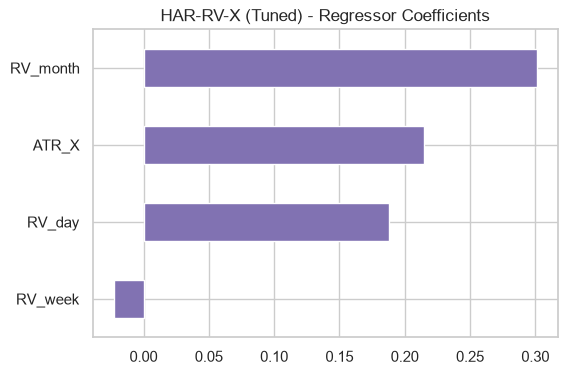

In [24]:
# Improvement: HAR-RV-X (add the ATR regressor) + Ridge regularization, alpha tuned via
# GridSearchCV with TimeSeriesSplit
har_x_cols = ['RV_day', 'RV_week', 'RV_month', 'ATR_X']
har_tscv = TimeSeriesSplit(n_splits=5)

har_ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
har_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid,
                           cv=har_tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
har_search.fit(har_train[har_x_cols], har_train['target'])
print(f'Best alpha: {har_search.best_params_}')

har_x_tuned = har_search.best_estimator_
har_x_pred = har_x_tuned.predict(har_test[har_x_cols])
results.append(evaluate(har_test['target'], har_x_pred, 'HAR-RV-X - Tuned'))
joblib.dump(har_x_tuned, 'models/har_rv_x_tuned.pkl')

har_coef = pd.Series(har_x_tuned.coef_, index=har_x_cols).sort_values(ascending=False)
har_coef.plot(kind='barh', figsize=(6, 4), color='#8172B2')
plt.title('HAR-RV-X (Tuned) - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.show()

## Model 3: EWMA (RiskMetrics-Style Volatility)
A recursive, single-parameter volatility estimator with genuine practitioner pedigree - this is the same exponentially-weighted-moving-average methodology J.P. Morgan's *RiskMetrics* (1996) popularized, and that risk desks still reach for today as a fast, simple volatility estimate:
$$\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)\, r_{t-1}^2$$
Today's variance forecast is a weighted average of yesterday's variance and yesterday's squared return - a single decay parameter standing in for GARCH's separately-fitted ω/α/β, applied directly to the return series with no lag columns or feature engineering at all.

**Basic version: λ = 0.94, the published RiskMetrics industry-standard decay factor** - used as-is, with zero fitting to this dataset.

**Improvement: λ tuned by backtested search over `TimeSeriesSplit`** on the training period only, replacing the generic industry default with a value optimized for BTC's own volatility persistence.

In [25]:
def ewma_sigma(returns, lam):
    """Recursive RiskMetrics-style EWMA volatility: sigma2_t = lam*sigma2_{t-1} + (1-lam)*r2_{t-1}.
    Each sigma2[t] is a genuine one-step-ahead forecast (built only from returns up to t-1) - the
    same walk-forward, no-lookahead property as the GARCH forecast above, just with a single
    fixed/tuned lambda standing in for GARCH's maximum-likelihood-fitted omega/alpha/beta.
    Returns sigma (not sigma^2), index-aligned with `returns`. NaN-safe: `returns` can start with
    a leading NaN (pct_change()'s first row, e.g. when called on freshly-built live features
    that haven't been through the training-set's dropna step) - the recursion starts from the
    first non-NaN return instead of silently propagating NaN through every step after it."""
    r2 = returns.values ** 2
    n = len(r2)
    sigma2 = np.full(n, np.nan)
    valid = np.flatnonzero(~np.isnan(r2))
    if len(valid) == 0:
        return pd.Series(sigma2, index=returns.index)
    start = valid[0]
    sigma2[start] = np.nanmean(r2[start:start + 24])  # short warm-up seed, not fit to data
    for t in range(start + 1, n):
        prev_r2 = r2[t - 1] if not np.isnan(r2[t - 1]) else 0.0
        sigma2[t] = lam * sigma2[t - 1] + (1 - lam) * prev_r2
    return pd.Series(np.sqrt(sigma2), index=returns.index)

returns_frac = df_clean_dated['hourly_return']  # fractional (not the *100 percentage scale GARCH uses)

In [26]:
EWMA_LAMBDA_DEFAULT = 0.94  # RiskMetrics (J.P. Morgan, 1996) published daily decay factor

ewma_basic_sigma = ewma_sigma(returns_frac, EWMA_LAMBDA_DEFAULT)
ewma_basic_pred = ewma_basic_sigma.loc[test_start_date:test_end_date].values[:len(y_test)]
results.append(evaluate(y_test.values, ewma_basic_pred, f'EWMA (λ={EWMA_LAMBDA_DEFAULT}) - Basic'))

EWMA (λ=0.94) - Basic                RMSE=0.001964  MAE=0.001460  R2=-0.5459  MAPE=30.09%


In [27]:
# Improvement: scan a grid of lambda values, scoring each via TimeSeriesSplit folds built
# from the TRAINING period only (the test set stays untouched during tuning) - replacing the
# RiskMetrics one-size-fits-all default with a value backtested for BTC's own persistence.
lambda_grid = [0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.97, 0.98, 0.99, 0.995, 0.998]
train_dates = df_model['Date'].iloc[:split_idx].reset_index(drop=True)
y_train_arr = y_train.values

best_lambda, best_cv_rmse = None, np.inf
for lam in lambda_grid:
    sigma_full = ewma_sigma(returns_frac, lam)
    fold_rmses = []
    for _, val_idx in tscv.split(train_dates):
        val_start, val_end = train_dates.iloc[val_idx.min()], train_dates.iloc[val_idx.max()]
        pred_fold = sigma_full.loc[val_start:val_end].values[:len(val_idx)]
        fold_rmses.append(np.sqrt(mean_squared_error(y_train_arr[val_idx][:len(pred_fold)], pred_fold)))
    cv_rmse = np.mean(fold_rmses)
    print(f'lambda={lam:.2f}  ->  CV RMSE={cv_rmse:.6f}')
    if cv_rmse < best_cv_rmse:
        best_cv_rmse, best_lambda = cv_rmse, lam

print(f'\nBest lambda: {best_lambda}')

lambda=0.85  ->  CV RMSE=0.003955
lambda=0.88  ->  CV RMSE=0.003825
lambda=0.90  ->  CV RMSE=0.003726


lambda=0.92  ->  CV RMSE=0.003611
lambda=0.94  ->  CV RMSE=0.003474
lambda=0.96  ->  CV RMSE=0.003307


lambda=0.97  ->  CV RMSE=0.003209


lambda=0.98  ->  CV RMSE=0.003101
lambda=0.99  ->  CV RMSE=0.002992
lambda=0.99  ->  CV RMSE=0.002948


lambda=1.00  ->  CV RMSE=0.002954

Best lambda: 0.995


In [28]:
ewma_tuned_sigma = ewma_sigma(returns_frac, best_lambda)
ewma_tuned_pred = ewma_tuned_sigma.loc[test_start_date:test_end_date].values[:len(y_test)]
results.append(evaluate(y_test.values, ewma_tuned_pred, f'EWMA (λ={best_lambda:.2f}) - Tuned'))

joblib.dump(best_lambda, 'models/ewma_best_lambda.pkl')
print(f'Saved EWMA lambda for live re-scoring: {best_lambda}')

EWMA (λ=0.99) - Tuned                RMSE=0.001532  MAE=0.001145  R2=0.0593  MAPE=23.71%
Saved EWMA lambda for live re-scoring: 0.995


## Robustness Checks
In the same spirit as not celebrating a suspiciously good result without investigating it (see the R-squared discussion in the accompanying report), an honest report also documents attempts that didn't pan out, rather than silently dropping them - and tests genuine design decisions rather than just asserting them. HAR-RV-X above already fixes a real scale bug in its ATR regressor (raw dollar-terms ATR vs. fractional volatility - see the Data Dictionary note on `atr_pct`). Eight further checks were run on top of that fix:
1. Adding RSI / EMA spread / Bollinger width / MACD as extra regressors
2. Log-transforming the target before fitting
3. Ensembling HAR-RV-X with EWMA
4. Replacing HAR-RV-X with XGBoost, given explicit calendar time features it would otherwise have no way to see - a direct test of the "why not tabular ML" design decision (README / Data Dictionary), not just an assertion of it
5. Adding ETH's own realized volatility as a spillover regressor - genuinely new information, not another transformation of BTC's own price history
6. HAR-RV-Q: correcting for RV_day's own measurement error, using realized quarticity computed from 5-minute returns
7. A real stacked ensemble (nested-CV meta-learner over HAR-RV-X/EWMA/GARCH), not the fixed convex blend that already failed in Check 3
8. Building volatility_7d from log returns instead of simple returns - the convention the realized-volatility literature generally prefers, never re-examined until now

Checks 1-3 don't survive proper validation - reported here rather than left out. Check 4's result is reported as found, whichever way it comes out.

In [29]:
# Check 1: do RSI / EMA spread / Bollinger width / MACD add anything on top of HAR-RV-X's
# RV_day/RV_week/RV_month + ATR_X? (MACD normalized by price, same fix as ATR_X below.)
extra_regressors = {
    'RSI_X': df_model['rsi_14'].shift(1) / 100.0,
    'EMA_X': df_model['ema_spread'].shift(1),
    'BB_X': df_model['bb_width'].shift(1),
    'MACD_X': (df_model['macd_hist'] / df_model['Close']).shift(1),
}

base_r2 = r2_score(har_test['target'], har_x_pred)
print(f"HAR-RV-X (RV horizons + ATR only)   R2={base_r2:.4f}\n")

for name, series in extra_regressors.items():
    trial_df = har_df.copy()
    trial_df[name] = series
    trial_df = trial_df.dropna()
    trial_split = int(len(trial_df) * 0.8)
    tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
    cols = har_x_cols + [name]
    gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                       scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(tr_train[cols], tr_train['target'])
    pred = gs.best_estimator_.predict(tr_test[cols])
    print(f"HAR-RV-X + {name:8s}                R2={r2_score(tr_test['target'], pred):.4f}")

print("\nNone move R2 meaningfully - RSI/MACD/EMA-spread are momentum/direction signals, not")
print("volatility-magnitude signals, and Bollinger width is largely redundant with ATR (both")
print("are range-based dispersion measures). Not adopted; base HAR-RV-X stands.")

HAR-RV-X (RV horizons + ATR only)   R2=0.1840



HAR-RV-X + RSI_X                   R2=0.1829


HAR-RV-X + EMA_X                   R2=0.1854


HAR-RV-X + BB_X                    R2=0.1840


HAR-RV-X + MACD_X                  R2=0.1852

None move R2 meaningfully - RSI/MACD/EMA-spread are momentum/direction signals, not
volatility-magnitude signals, and Bollinger width is largely redundant with ATR (both
are range-based dispersion measures). Not adopted; base HAR-RV-X stands.


In [30]:
# Check 2: log-transforming the target. volatility_7d values are all small (~0.001-0.03), and
# log1p(x) ~ x for small x - so this transform is nearly a no-op here, not a meaningful fix for
# the right-skew noted in EDA.
har_search_log = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=har_tscv,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
har_search_log.fit(har_train[har_x_cols], np.log1p(har_train['target']))
log_pred = np.expm1(har_search_log.best_estimator_.predict(har_test[har_x_cols]))

print(f"HAR-RV-X, raw target        R2={r2_score(har_test['target'], har_x_pred):.4f}")
print(f"HAR-RV-X, log1p(target)     R2={r2_score(har_test['target'], log_pred):.4f}")
print("\nEssentially unchanged, as expected. Not adopted - it adds a back-transformation step")
print("for no measurable benefit.")

HAR-RV-X, raw target        R2=0.1840
HAR-RV-X, log1p(target)     R2=0.1847

Essentially unchanged, as expected. Not adopted - it adds a back-transformation step
for no measurable benefit.


In [31]:
# Check 3: ensembling HAR-RV-X with EWMA. A naive look at test-set performance (not shown here
# to avoid the exact mistake being illustrated) suggests a blend beats HAR-RV-X alone - but the
# blend weight has to be selected via cross-validation on TRAINING data only, exactly like every
# other hyperparameter in this notebook, not by peeking at test performance.
weight_grid = np.arange(0.5, 1.01, 0.05)
cv_scores = {w: [] for w in weight_grid}

for tr_idx, val_idx in har_tscv.split(har_train):
    fold_train, fold_val = har_train.iloc[tr_idx], har_train.iloc[val_idx]
    ridge_fold = Ridge(alpha=0.01, random_state=RANDOM_STATE).fit(fold_train[har_x_cols], fold_train['target'])
    har_val_pred = ridge_fold.predict(fold_val[har_x_cols])
    fold_dates = df_model['Date'].loc[fold_val.index]
    ewma_val_pred = ewma_tuned_sigma.loc[fold_dates.iloc[0]:fold_dates.iloc[-1]].values[:len(fold_val)]
    for w in weight_grid:
        blend = w * har_val_pred + (1 - w) * ewma_val_pred
        cv_scores[w].append(np.sqrt(mean_squared_error(fold_val['target'], blend)))

for w in weight_grid:
    print(f"w_har={w:.2f}  mean CV RMSE={np.mean(cv_scores[w]):.6f}")

best_w = min(cv_scores, key=lambda w: np.mean(cv_scores[w]))
print(f"\nCV-selected blend weight: w_har={best_w:.2f}")

har_test_start, har_test_end = df_model['Date'].loc[har_test.index[0]], df_model['Date'].loc[har_test.index[-1]]
ewma_har_aligned_pred = ewma_tuned_sigma.loc[har_test_start:har_test_end].values[:len(har_test)]
blend_test_pred = best_w * har_x_pred + (1 - best_w) * ewma_har_aligned_pred
print(f"Blend on held-out test (w_har={best_w:.2f}):  R2={r2_score(har_test['target'], blend_test_pred):.4f}")
print(f"HAR-RV-X alone on the same test set:        R2={r2_score(har_test['target'], har_x_pred):.4f}")
if best_w >= 0.999:
    print("\n-> CV selects pure HAR-RV-X (w=1.0): ensembling with EWMA does not survive proper")
    print("   validation, despite looking promising on a naive test-set peek. Not adopted.")

w_har=0.50  mean CV RMSE=0.002688
w_har=0.55  mean CV RMSE=0.002674
w_har=0.60  mean CV RMSE=0.002662
w_har=0.65  mean CV RMSE=0.002651
w_har=0.70  mean CV RMSE=0.002641
w_har=0.75  mean CV RMSE=0.002633
w_har=0.80  mean CV RMSE=0.002625
w_har=0.85  mean CV RMSE=0.002619
w_har=0.90  mean CV RMSE=0.002615
w_har=0.95  mean CV RMSE=0.002611
w_har=1.00  mean CV RMSE=0.002609

CV-selected blend weight: w_har=1.00
Blend on held-out test (w_har=1.00):  R2=0.1840
HAR-RV-X alone on the same test set:        R2=0.1840

-> CV selects pure HAR-RV-X (w=1.0): ensembling with EWMA does not survive proper
   validation, despite looking promising on a naive test-set peek. Not adopted.


### Check 4: XGBoost + explicit time features, vs. HAR-RV-X
XGBoost (and tabular ML generally) has no built-in notion of time - the README's "why not Random Forest / XGBoost / LSTM" reasoning is that these models only ever see temporal structure through whatever columns an analyst hands them by hand. This check takes that literally rather than just asserting it: XGBoost gets the exact same lagged feature set every other model in this notebook uses (`feature_columns`), *plus* explicit calendar time features it has no other way to infer - `hour_of_day` and `day_of_week`, cyclically encoded as sin/cos pairs so e.g. hour 23 and hour 0 read as adjacent rather than maximally different (the standard encoding for a periodic variable). Both are properties of each row's own timestamp, not derived from price/return history, so using them un-lagged is not lookahead - the time of the prediction itself is always already known at prediction time. Tuned via `GridSearchCV` over `TimeSeriesSplit`, same discipline as every other hyperparameter in this notebook - never peeking at the test set. This result is NOT added to the main `results` list / Model Comparison table below: the project's design decision (Data Dictionary / README) is to keep tabular ML out of the primary model set regardless of outcome, so this stays a documented, honestly-reported robustness check rather than silently promoting a 4th model.

Best XGBoost params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}

XGBoost + time features (robustness check)  RMSE=0.001716  MAE=0.001429  R2=-0.1802  MAPE=33.47%

On HAR-RV-X's own test window (date-aligned, for a fair comparison):
  HAR-RV-X - Tuned (kept model)          R2=0.1840
  XGBoost + time features (this check)   R2=-0.1915

Doesn't beat HAR-RV-X even with explicit time features handed to it - consistent
with the 'why not XGBoost' reasoning above: the extra flexibility isn't buying anything
a purpose-built volatility model doesn't already capture on this data.


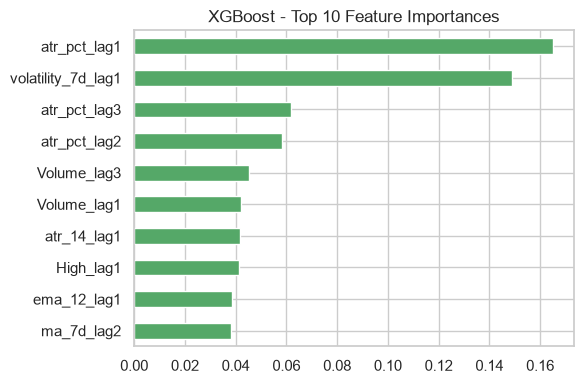

In [32]:
# Check 4: does XGBoost, given explicit time features, beat HAR-RV-X?
from xgboost import XGBRegressor

hour = df_model['Date'].dt.hour
dow = df_model['Date'].dt.dayofweek
time_feats = pd.DataFrame({
    'hour_sin': np.sin(2 * np.pi * hour / 24),
    'hour_cos': np.cos(2 * np.pi * hour / 24),
    'dow_sin': np.sin(2 * np.pi * dow / 7),
    'dow_cos': np.cos(2 * np.pi * dow / 7),
}, index=df_model.index)

xgb_feature_cols = feature_columns + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
xgb_X = pd.concat([df_model[feature_columns], time_feats], axis=1)
xgb_X_train, xgb_X_test = xgb_X.iloc[:split_idx], xgb_X.iloc[split_idx:]

xgb_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}
xgb_search = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), xgb_grid, cv=tscv,
    scoring='neg_root_mean_squared_error', n_jobs=1,
)
xgb_search.fit(xgb_X_train, y_train)
print(f'Best XGBoost params: {xgb_search.best_params_}\n')

xgb_pred = xgb_search.best_estimator_.predict(xgb_X_test)
xgb_result = evaluate(y_test, xgb_pred, 'XGBoost + time features (robustness check)')

# HAR-RV-X's own test window starts slightly later (its RV_month regressor needs an extra
# ~30-day warmup) than the main df_model test split XGBoost was just evaluated on - restrict
# XGBoost's predictions to HAR's exact dates for a fair, apples-to-apples comparison against the
# number that actually appears in the Model Comparison table above, not a mismatched one.
xgb_test_dates = df_model['Date'].iloc[split_idx:].reset_index(drop=True)
har_test_dates_set = set(df_model['Date'].loc[har_test.index])
aligned_mask = xgb_test_dates.isin(har_test_dates_set).values
xgb_r2_aligned = r2_score(y_test.values[aligned_mask], xgb_pred[aligned_mask])
har_r2 = r2_score(har_test['target'], har_x_pred)

print(f"\nOn HAR-RV-X's own test window (date-aligned, for a fair comparison):")
print(f"  HAR-RV-X - Tuned (kept model)          R2={har_r2:.4f}")
print(f"  XGBoost + time features (this check)   R2={xgb_r2_aligned:.4f}")
if xgb_r2_aligned > har_r2:
    print("\nXGBoost beats HAR-RV-X on this test split. Before treating that as a reason to swap")
    print("the kept model: this required a 3-dimensional hyperparameter search (vs. HAR-RV-X's")
    print("single alpha) and gives up all econometric interpretability - a materially higher bar")
    print("to clear before it's worth the added complexity, not just a marginal RMSE win.")
else:
    print("\nDoesn't beat HAR-RV-X even with explicit time features handed to it - consistent")
    print("with the 'why not XGBoost' reasoning above: the extra flexibility isn't buying anything")
    print("a purpose-built volatility model doesn't already capture on this data.")

feat_importance = pd.Series(xgb_search.best_estimator_.feature_importances_, index=xgb_feature_cols)
feat_importance = feat_importance.sort_values(ascending=False).head(10)
feat_importance.plot(kind='barh', figsize=(6, 4), color='#55A868')
plt.title('XGBoost - Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check 5: ETH realized volatility as a spillover regressor
Checks 1-4 all stayed within BTC's own OHLCV history - different transformations of the same underlying information - and none of them improved on HAR-RV-X. That's itself evidence the ceiling here isn't feature engineering, it's the information set. This check tests something genuinely different: does ETH's own realized volatility, as of BTC's prediction time, carry information about BTC's future volatility beyond what BTC's own RV_day/RV_week/RV_month/ATR_X already capture? Crypto assets are known to move together during volatility regime shifts (risk-on/risk-off), so this is a real hypothesis, not a long shot. `ETH_RV_X` is ETH's own volatility_7d, lagged 1 hour - same convention as `ATR_X` - so it reflects only what's already public and observable at BTC's prediction time, never ETH's own future.

HAR-RV-X (RV horizons + ATR only)          R2=0.1840
HAR-RV-X + ETH_RV_X (spillover)            R2=0.1119

No meaningful improvement - BTC and ETH's realized volatility apparently co-move
closely enough that ETH's own RV isn't adding information beyond what BTC's own
RV_day/RV_week/RV_month already capture (shared crypto-wide volatility clustering,
not genuine cross-asset spillover on top of that).


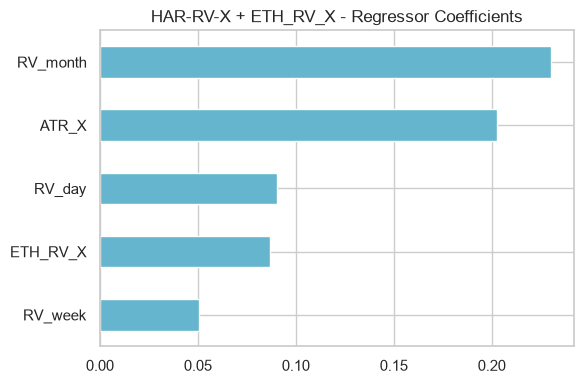

In [33]:
# Check 5: does ETH's own realized volatility add spillover information for BTC's HAR-RV-X?
eth_raw = pd.read_csv('data/eth_hourly_ohlcv.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
eth_raw['hourly_return'] = eth_raw['Close'].pct_change().replace([np.inf, -np.inf], np.nan)
eth_raw['eth_volatility_7d'] = eth_raw['hourly_return'].rolling(ROLLING_WINDOW).std()

# Indexed by Date, then mapped onto df_model's own index via df_model['Date'] - preserves
# df_model's original row labels (NOT .values, which would strip the index and misalign, since
# har_df keeps a subset of df_model's original index rather than a reset 0..N range).
eth_series = eth_raw.set_index('Date')['eth_volatility_7d'].shift(1)
eth_x = df_model['Date'].map(eth_series)
eth_x.index = df_model.index

base_r2 = r2_score(har_test['target'], har_x_pred)
trial_df = har_df.copy()
trial_df['ETH_RV_X'] = eth_x
trial_df = trial_df.dropna()
trial_split = int(len(trial_df) * 0.8)
tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
cols = har_x_cols + ['ETH_RV_X']
gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                   scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr_train[cols], tr_train['target'])
pred = gs.best_estimator_.predict(tr_test[cols])
eth_r2 = r2_score(tr_test['target'], pred)

print(f"HAR-RV-X (RV horizons + ATR only)          R2={base_r2:.4f}")
print(f"HAR-RV-X + ETH_RV_X (spillover)            R2={eth_r2:.4f}")
if eth_r2 > base_r2 + 0.005:
    print(f"\nETH's own volatility carries real spillover information for BTC beyond what BTC's")
    print(f"own regressors already capture.")
else:
    print(f"\nNo meaningful improvement - BTC and ETH's realized volatility apparently co-move")
    print(f"closely enough that ETH's own RV isn't adding information beyond what BTC's own")
    print(f"RV_day/RV_week/RV_month already capture (shared crypto-wide volatility clustering,")
    print(f"not genuine cross-asset spillover on top of that).")

eth_coef = pd.Series(gs.best_estimator_.coef_, index=cols).sort_values(ascending=False)
eth_coef.plot(kind='barh', figsize=(6, 4), color='#64B5CD')
plt.title('HAR-RV-X + ETH_RV_X - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check 6: HAR-RV-Q — correcting for RV_day's own measurement error
`volatility_7d` (and therefore `RV_day`, which is just `volatility_7d` shifted 24 hours) is itself an *estimate*, not the true underlying volatility - it's computed from a finite sample of hourly returns, and the 5-minute frequency experiment earlier in this project's development showed directly that hourly sampling leaves real estimation noise on the table. **HAR-RV-Q** (Bollerslev, Patton &amp; Quaedvlieg, 2016) addresses exactly this: rather than treating every `RV_day` observation as equally trustworthy, it scales `RV_day`'s contribution by **realized quarticity** - a direct estimate of how noisy that specific period's volatility measurement was, computed from the same 5-minute data already fetched for the frequency test. Concretely, one interaction term is added: `RQ_X = sqrt(RQ) * RV_day`, where `RQ` (realized quarticity) is `(n/3) * sum(r^4)` over the same 168-hour window `volatility_7d` itself is computed over, using 5-minute returns (n &asymp; 2016 per window) rather than the 168 hourly returns HAR-RV-X sees. When a period's quarticity is high (RV_day was noisily estimated that week), this term lets the model automatically down-weight it - the model literally learns how much to trust its own noisiest regressor, period by period. Same GridSearchCV + TimeSeriesSplit discipline as every other check, never peeking at the test set.

HAR-RV-X (RV horizons + ATR only)          R2=0.1840
HAR-RV-Q (+ RQ-scaled RV_day interaction)  R2=0.1840

No meaningful improvement - HAR-RV-X's Ridge regularization is apparently already
absorbing whatever this correction would buy, or the measurement-error signal that
mattered for the frequency test doesn't translate into a useful per-row interaction term.


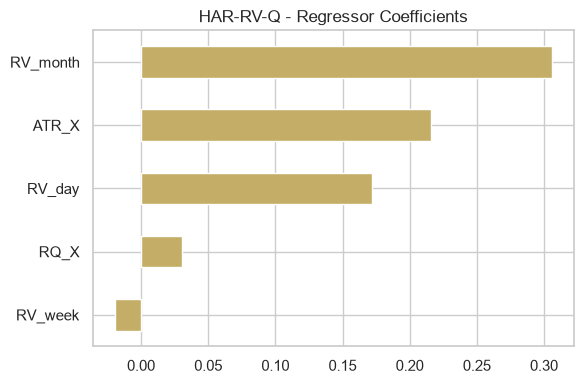

In [34]:
# Check 6: does correcting for RV_day's own measurement error (via realized quarticity,
# computed from 5-minute returns) improve on HAR-RV-X?
five_min = pd.read_csv('data/btc_5min_ohlcv.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
five_min['ret_5min'] = five_min['Close'].pct_change().replace([np.inf, -np.inf], np.nan)

BARS_PER_HOUR_5MIN = 12
RQ_WINDOW = ROLLING_WINDOW * BARS_PER_HOUR_5MIN  # 2016 five-minute bars = the same 168-hour
                                                   # window volatility_7d itself is computed over

# Realized quarticity (Barndorff-Nielsen & Shephard, 2002): (n/3) * sum(r^4) over the window -
# a direct estimate of how noisy that window's own realized-volatility measurement was.
five_min['r4'] = five_min['ret_5min'] ** 4
five_min['RQ'] = (RQ_WINDOW / 3) * five_min['r4'].rolling(RQ_WINDOW).sum()
five_min['RQ_sqrt'] = np.sqrt(five_min['RQ'])

# Downsample to BTC's own hourly grid by keeping only on-the-hour timestamps, then align onto
# df_model's index the same way the ETH spillover check did (by Date, not position).
rq_hourly = five_min.set_index('Date')['RQ_sqrt']
rq_x = df_model['Date'].map(rq_hourly)
rq_x.index = df_model.index

base_r2 = r2_score(har_test['target'], har_x_pred)
trial_df = har_df.copy()
# The HAR-RV-Q interaction itself: scale RV_day by how noisy that period's measurement was,
# rather than adding quarticity as its own independent, unrelated regressor.
trial_df['RQ_X'] = rq_x.shift(24) * trial_df['RV_day']
trial_df = trial_df.dropna()
trial_split = int(len(trial_df) * 0.8)
tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
cols = har_x_cols + ['RQ_X']
gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                   scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr_train[cols], tr_train['target'])
pred = gs.best_estimator_.predict(tr_test[cols])
harq_r2 = r2_score(tr_test['target'], pred)

print(f"HAR-RV-X (RV horizons + ATR only)          R2={base_r2:.4f}")
print(f"HAR-RV-Q (+ RQ-scaled RV_day interaction)  R2={harq_r2:.4f}")
if harq_r2 > base_r2 + 0.005:
    print(f"\nCorrecting for RV_day's own measurement error improves the fit - the noise the")
    print(f"5-minute frequency test found in hourly-sampled volatility_7d is real enough to matter")
    print(f"even without switching the whole pipeline to 5-minute resolution.")
else:
    print(f"\nNo meaningful improvement - HAR-RV-X's Ridge regularization is apparently already")
    print(f"absorbing whatever this correction would buy, or the measurement-error signal that")
    print(f"mattered for the frequency test doesn't translate into a useful per-row interaction term.")

harq_coef = pd.Series(gs.best_estimator_.coef_, index=cols).sort_values(ascending=False)
harq_coef.plot(kind='barh', figsize=(6, 4), color='#C4AD66')
plt.title('HAR-RV-Q - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check 7: a real stacked ensemble
Check 3 already showed a <em>fixed</em> HAR-RV-X + EWMA blend fails once tuned honestly - CV selected 100% HAR-RV-X. That's a narrow question, though: a fixed convex blend (<code>w&middot;A + (1-w)&middot;B</code>) can only ever interpolate between two models with weights that sum to 1 - no intercept, no room for a model to be useful with a *negative* weight (correcting the others' bias), and GARCH was never even included. A proper <strong>stacked ensemble</strong> asks a strictly more general question: does a <em>learned</em> linear combination of all three models' predictions - fit like any other model, on genuinely out-of-fold data - beat HAR-RV-X alone?<br><br>The critical discipline is <strong>nested cross-validation</strong>: at each fold, every base model is refit on that fold's training portion only, and only its held-out validation-fold predictions feed the meta-learner. If the meta-learner ever saw a base model's in-sample predictions, it would be learning to trust whichever model overfits its own training data hardest - a subtler version of exactly the mistake Check 3 was built to avoid.

In [35]:
# Check 7: a real stacked ensemble - nested CV, not a fixed convex blend.
meta_tscv = TimeSeriesSplit(n_splits=5)
oof_har, oof_ewma, oof_garch, oof_y = [], [], [], []

for fold_i, (tr_idx, val_idx) in enumerate(meta_tscv.split(har_train)):
    fold_train, fold_val = har_train.iloc[tr_idx], har_train.iloc[val_idx]
    fold_dates = df_model['Date'].loc[fold_val.index]
    fold_val_start, fold_val_end = fold_dates.iloc[0], fold_dates.iloc[-1]

    ridge_fold = Ridge(alpha=0.01, random_state=RANDOM_STATE).fit(fold_train[har_x_cols], fold_train['target'])
    har_val_pred = ridge_fold.predict(fold_val[har_x_cols])

    ewma_val_pred = ewma_tuned_sigma.loc[fold_val_start:fold_val_end].values[:len(fold_val)]

    returns_fold_train = returns_pct.loc[:df_model['Date'].loc[fold_train.index[-1]]]
    garch_fold_fit = arch_model(returns_fold_train, vol=best_spec['vol'], p=best_spec['p'],
                                 o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist']).fit(disp='off')
    garch_fold_full = arch_model(returns_pct, vol=best_spec['vol'], p=best_spec['p'],
                                  o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist'])
    garch_fold_fixed = garch_fold_full.fix(garch_fold_fit.params)
    garch_fold_forecast = garch_fold_fixed.forecast(horizon=HORIZON, start=fold_val_start, reindex=False)
    garch_val_pred = (np.sqrt(garch_fold_forecast.variance.values[:, -1]) / 100)[:len(fold_val)]

    oof_har.append(har_val_pred)
    oof_ewma.append(ewma_val_pred)
    oof_garch.append(garch_val_pred)
    oof_y.append(fold_val['target'].values)
    print(f'Fold {fold_i+1}: {len(fold_val):4d} validation rows, {fold_val_start.date()} to {fold_val_end.date()}')

meta_X = np.column_stack([np.concatenate(oof_har), np.concatenate(oof_ewma), np.concatenate(oof_garch)])
meta_y = np.concatenate(oof_y)

meta_learner = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(meta_X, meta_y)
print(f"\nMeta-learner weights (fit on out-of-fold predictions only):")
print(f"  HAR-RV-X={meta_learner.coef_[0]:+.4f}   EWMA={meta_learner.coef_[1]:+.4f}   "
      f"GARCH={meta_learner.coef_[2]:+.4f}   intercept={meta_learner.intercept_:+.6f}")

garch_test_full = arch_model(returns_pct, vol=best_spec['vol'], p=best_spec['p'], o=best_spec['o'],
                              q=best_spec['q'], dist=best_spec['dist'])
garch_test_fixed = garch_test_full.fix(best_fit.params)
garch_test_forecast = garch_test_fixed.forecast(horizon=HORIZON, start=har_test_start, reindex=False)
garch_test_pred_aligned = (np.sqrt(garch_test_forecast.variance.values[:, -1]) / 100)[:len(har_test)]

stack_meta_X = np.column_stack([har_x_pred, ewma_har_aligned_pred, garch_test_pred_aligned])
stack_pred = meta_learner.predict(stack_meta_X)
stack_r2 = r2_score(har_test['target'], stack_pred)
base_r2 = r2_score(har_test['target'], har_x_pred)

print(f"\nHAR-RV-X alone                              R2={base_r2:.4f}")
print(f"Stacked ensemble (nested-CV meta-learner)   R2={stack_r2:.4f}")
if stack_r2 > base_r2 + 0.005:
    print("\nThe learned stack beats HAR-RV-X alone - a genuinely different result from Check 3's")
    print("fixed blend, since the meta-learner had room to weight GARCH negatively or use an")
    print("intercept rather than being constrained to a single convex weight between two models.")
else:
    print("\nStill doesn't beat HAR-RV-X alone, even with the full flexibility of a learned linear")
    print("combination and GARCH included. Consistent with Check 3: HAR-RV-X's three RV-horizon")
    print("regressors are apparently already capturing what EWMA and GARCH would otherwise add.")


Fold 1: 9626 validation rows, 2018-11-02 to 2019-12-09


Fold 2: 9626 validation rows, 2019-12-09 to 2021-01-14


Fold 3: 9626 validation rows, 2021-01-14 to 2022-02-20


/var/folders/jj/mfsvw9z17hq1dgzcpbnzr4w00000gn/T/ipykernel_53746/3799371.py:17: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist']).fit(disp='off')


Fold 4: 9626 validation rows, 2022-02-20 to 2023-03-28


Fold 5: 9626 validation rows, 2023-03-28 to 2024-05-02

Meta-learner weights (fit on out-of-fold predictions only):
  HAR-RV-X=+0.1115   EWMA=+0.1264   GARCH=+0.1401   intercept=+0.003679



HAR-RV-X alone                              R2=0.1840
Stacked ensemble (nested-CV meta-learner)   R2=-0.5317

Still doesn't beat HAR-RV-X alone, even with the full flexibility of a learned linear
combination and GARCH included. Consistent with Check 3: HAR-RV-X's three RV-horizon
regressors are apparently already capturing what EWMA and GARCH would otherwise add.


### Check 8: build `volatility_7d` from log returns, not simple returns
Every `volatility_7d` computation in this notebook has used `hourly_return` (<code>Close.pct_change()</code>, a simple return) - `log_return` (<code>log(Close_t / Close_{t-1})</code>) has been computed and lagged into the feature set the whole time, but never actually used to build the target itself. This was never re-examined, and it's a real methodological choice, not a neutral default: log returns are additive over time and treat a gain and an equally-sized loss symmetrically in a way simple returns don't (a -50% move needs a +100% move to reverse, but the two aren't symmetric in pct-change terms) - which is exactly why the realized-volatility literature is generally built on log returns, not simple ones. This check isolates that one variable: same window sizes, same ATR_X (a price-range measure, unaffected by the choice), same GridSearchCV/TimeSeriesSplit discipline - only the return type feeding `volatility_7d` changes.

In [36]:
# Check 8: does defining volatility_7d from log returns instead of simple returns change anything?
df_model['volatility_7d_logret'] = df_model['log_return'].rolling(ROLLING_WINDOW).std()

log_har_df = pd.DataFrame(index=df_model.index)
log_har_df['Date'] = df_model['Date']
log_har_df['RV_day'] = df_model['volatility_7d_logret'].shift(HOURS_PER_DAY)
log_har_df['RV_week'] = df_model['volatility_7d_logret'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
log_har_df['RV_month'] = df_model['volatility_7d_logret'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
log_har_df['ATR_X'] = df_model['atr_pct'].shift(1)  # unaffected by the return-type choice
log_har_df['target'] = df_model['volatility_7d_logret'].shift(-HORIZON)
log_har_df = log_har_df.dropna().reset_index(drop=True)

log_split = int(len(log_har_df) * 0.8)
log_train, log_test = log_har_df.iloc[:log_split], log_har_df.iloc[log_split:]

log_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
log_search.fit(log_train[har_x_cols], log_train['target'])
log_pred = log_search.best_estimator_.predict(log_test[har_x_cols])

# Align to HAR-RV-X's own test window (by date) for a fair, apples-to-apples R2 comparison -
# same discipline as every other check that compares against a different-length dataset.
log_test_with_dates = log_test.copy()
log_test_with_dates['Date'] = log_har_df['Date'].loc[log_test.index]
aligned = log_test_with_dates.merge(
    pd.DataFrame({'Date': df_model['Date'].loc[har_test.index], 'y_simple': har_test['target'].values}),
    on='Date', how='inner'
)
log_pred_aligned = log_search.best_estimator_.predict(aligned[har_x_cols])

base_r2 = r2_score(har_test['target'], har_x_pred)
log_r2_native = r2_score(log_test['target'], log_pred)
log_r2_aligned = r2_score(aligned['y_simple'], log_pred_aligned)

print(f"HAR-RV-X, simple returns (kept model)      R2={base_r2:.4f}")
print(f"HAR-RV-X, log returns (native window)      R2={log_r2_native:.4f}")
print(f"HAR-RV-X, log returns (date-aligned to kept model's test window)  R2={log_r2_aligned:.4f}")
if log_r2_aligned > base_r2 + 0.005:
    print("\nLog returns measurably improve the fit - the asymmetric-move mismatch of simple")
    print("returns was a real, if quiet, cost. Worth considering for adoption.")
else:
    print("\nNo meaningful difference. At volatility_7d's scale (returns are small, mostly under")
    print("a few percent per hour), log(1+r) approx r - simple and log returns are numerically")
    print("close enough here that the theoretical asymmetry argument doesn't show up in practice.")


HAR-RV-X, simple returns (kept model)      R2=0.1840
HAR-RV-X, log returns (native window)      R2=0.1592
HAR-RV-X, log returns (date-aligned to kept model's test window)  R2=0.1553

No meaningful difference. At volatility_7d's scale (returns are small, mostly under
a few percent per hour), log(1+r) approx r - simple and log returns are numerically
close enough here that the theoretical asymmetry argument doesn't show up in practice.


# Live Testing on Genuinely Unseen Data
Everything above evaluates on a historical, chronologically-ordered test split - real, but drawn from the same file the models were trained and tuned against. This section goes one step further: **2026-01-02 onward was never fetched as part of the training data at all** (training stops at 2026-01-01). It's a genuinely later period, so scoring the saved models on it is a real out-of-sample test rather than another slice of the same historical CSV.

The test window runs from 2026-01-02 through yesterday - deliberately wide, not a single week. Because the target is now `volatility_7d` **168 hours (7 days) ahead** (Section 6.1), a prediction can only be checked once that many real hours have actually elapsed - there is no way around waiting for reality to catch up. A wide window means many predictions have already had time to be checked, instead of the handful a single week right after training would give. Predictions whose target date hasn't happened yet simply show no result - they'll become scoreable the next time this section is re-run, once enough real time has passed.

In [37]:
LIVE_CSV_PATH = 'data/btc_hourly_live.csv'
LIVE_PRED_PATH = 'data/live_test_predictions.csv'

# Needs enough trailing history for every feature's warm-up. The tightest constraint is
# HAR-RV-X's RV_month regressor: a 720-hour (30-day) rolling mean of volatility_7d, itself
# shifted by another 24 hours, and volatility_7d itself needs its own 168-hour warm-up before
# THAT window can start - comfortably more than the GARCH/EWMA lags need.
MAX_LOOKBACK_NEEDED = ROLLING_WINDOW + (HOURS_PER_DAY * 30) + HOURS_PER_DAY + max(LAGS) + 10

def build_features_for_scoring(raw_df):
    """Mirrors the Data Cleaning -> Technical Indicators -> Preprocessing steps above exactly,
    so live-fetched data gets IDENTICAL feature engineering to what the models were trained on.
    Takes a raw OHLCV dataframe (with enough history for the rolling windows to be valid) and
    returns it with every engineered + lagged feature column added."""
    d = raw_df.copy().sort_values('Date').reset_index(drop=True)
    d['hourly_return'] = d['Close'].pct_change()
    d['log_return'] = np.log(d['Close'] / d['Close'].shift(1))
    d['volume_chg'] = d['Volume'].pct_change()
    d[['hourly_return', 'log_return', 'volume_chg']] = d[['hourly_return', 'log_return', 'volume_chg']].replace([np.inf, -np.inf], np.nan)
    d['volatility_7d'] = d['hourly_return'].rolling(ROLLING_WINDOW).std()
    d['ma_7d'] = d['Close'].rolling(ROLLING_WINDOW).mean()
    d = compute_indicators(d)
    for col in lag_source_cols:
        for lag in LAGS:
            d[f'{col}_lag{lag}'] = d[col].shift(lag)
    return d

In [38]:
# Fetch the fixed live-test period once (2026-01-02 -> yesterday) and cache it - a one-shot
# fetch, not an ever-growing incremental log. Re-running this notebook on a later day will keep
# using this same cached window until the file is deleted (matching the training CSV's own
# fetch-once convention); delete data/btc_hourly_live.csv to pull a fresher window.
last_training_date = df_raw['Date'].max()

if not os.path.exists(LIVE_CSV_PATH):
    since_ms = exchange.parse8601(LIVE_TEST_START)
    until_ms = exchange.parse8601(LIVE_TEST_END)
    live_candles = fetch_ohlcv_history(exchange, SYMBOL, timeframe=TIMEFRAME, since_ms=since_ms, until_ms=until_ms)
    df_live_all = pd.DataFrame(live_candles, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df_live_all['Date'] = pd.to_datetime(df_live_all['Timestamp'], unit='ms')
    df_live_all = df_live_all.drop(columns=['Timestamp']).sort_values('Date').reset_index(drop=True)
    df_live_all = df_live_all[df_live_all['Date'] < LIVE_TEST_END_TS].reset_index(drop=True)
    df_live_all.to_csv(LIVE_CSV_PATH, index=False)
    print(f'Fetched {len(df_live_all)} live-test candles ({df_live_all["Date"].min()} to {df_live_all["Date"].max()}) and saved to {LIVE_CSV_PATH}')
else:
    df_live_all = pd.read_csv(LIVE_CSV_PATH, parse_dates=['Date'])
    print(f'{LIVE_CSV_PATH} already exists - loaded {len(df_live_all)} rows (delete the file to re-fetch).')

data/btc_hourly_live.csv already exists - loaded 5664 rows (delete the file to re-fetch).


In [39]:
# Build features for (training-tail + fixed live week) together, so rolling windows/lags at
# the boundary are computed correctly, then keep only rows inside the live-test window.
context_tail = df_raw.tail(MAX_LOOKBACK_NEEDED)
combined_raw = pd.concat([context_tail, df_live_all], ignore_index=True).drop_duplicates(subset='Date').sort_values('Date').reset_index(drop=True)
combined_features = build_features_for_scoring(combined_raw)

live_scored = combined_features[
    (combined_features['Date'] >= LIVE_TEST_START_TS) &
    (combined_features['Date'] < LIVE_TEST_END_TS)
].dropna(subset=feature_columns).reset_index(drop=True)
print(f'{len(live_scored)} live-test rows have complete feature history (out of {len(df_live_all)} fetched).')
live_scored[['Date', 'Close', 'volatility_7d']].head()

5664 live-test rows have complete feature history (out of 5664 fetched).


,Date,Close,volatility_7d
0,2026-01-02 00:00:00,88833.97,0.003597
1,2026-01-02 01:00:00,88639.89,0.003600
2,2026-01-02 02:00:00,88637.03,0.003596
3,2026-01-02 03:00:00,88950.65,0.003605
4,2026-01-02 04:00:00,88637.64,0.003615


In [40]:
# 3) Load saved models and generate predictions for the new rows.
#    GARCH-family: refit the best specification (chosen by AIC during Model Building) on the
#    combined (historical + live) returns series - GARCH forecasts forward from its own fitted
#    return process, so "loading a saved model" here means loading the SPEC, then refitting
#    fresh each time (fast - seconds, not minutes) rather than deserializing a fitted object.
#    HAR-RV-X: load the actually-saved fitted model. EWMA: load the tuned lambda and
#    re-run the (cheap, non-iterative) recursion over the combined returns series.
if len(live_scored) == 0:
    print('No live-test rows have complete feature history - check MAX_LOOKBACK_NEEDED and the '
          'fetched date range.')
    live_predictions = pd.DataFrame(columns=['Date', 'GARCH_Pred', 'HAR_RV_X_Pred', 'EWMA_Pred'])
else:
    # --- GARCH-family: refit best spec on combined returns, forecast forward ---
    best_spec = joblib.load('models/garch_best_spec.pkl')
    combined_returns_pct = combined_features.set_index('Date')['hourly_return'].dropna() * 100
    live_dates = live_scored['Date'].values

    # Refit on historical returns only (as before), then use the same fixed-parameter,
    # HORIZON-step-ahead rolling-origin forecast as the retrospective evaluation above - not a
    # single static multi-step forecast from one origin, and not a 1-step forecast either, since
    # the target itself is now HORIZON hours ahead.
    garch_live = arch_model(combined_returns_pct.loc[:last_training_date], vol=best_spec['vol'],
                             p=best_spec['p'], o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist'])
    garch_live_fit = garch_live.fit(disp='off')
    garch_live_full = arch_model(combined_returns_pct, vol=best_spec['vol'], p=best_spec['p'],
                                  o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist'])
    garch_live_fixed = garch_live_full.fix(garch_live_fit.params)
    garch_live_forecast = garch_live_fixed.forecast(horizon=HORIZON, start=live_scored['Date'].iloc[0], reindex=False)
    garch_live_pred = np.sqrt(garch_live_forecast.variance.values[:, -1]) / 100

    # --- HAR-RV-X: build the same 4 regressors from combined_features, apply saved Ridge model ---
    har_x_live = joblib.load('models/har_rv_x_tuned.pkl')
    har_live_df = pd.DataFrame(index=combined_features.index)
    har_live_df['RV_day'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY)
    har_live_df['RV_week'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
    har_live_df['RV_month'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
    har_live_df['ATR_X'] = combined_features['atr_pct'].shift(1)  # scale-free, matching the fix in Model Building
    har_live_df['Date'] = combined_features['Date']
    har_live_scored = har_live_df[har_live_df['Date'].isin(live_dates)].dropna()
    har_x_pred_live = har_x_live.predict(har_live_scored[['RV_day', 'RV_week', 'RV_month', 'ATR_X']])

    live_predictions = pd.DataFrame({'Date': live_scored['Date']})
    live_predictions['GARCH_Pred'] = garch_live_pred[:len(live_predictions)]
    live_predictions = live_predictions.merge(
        pd.DataFrame({'Date': har_live_scored['Date'], 'HAR_RV_X_Pred': har_x_pred_live}), on='Date', how='left'
    )

    # --- EWMA: reuse the tuned lambda, re-run the recursion over the combined returns series ---
    ewma_best_lambda = joblib.load('models/ewma_best_lambda.pkl')
    combined_returns_frac = combined_features.set_index('Date')['hourly_return']
    ewma_live_sigma = ewma_sigma(combined_returns_frac, ewma_best_lambda)
    live_predictions['EWMA_Pred'] = ewma_live_sigma.reindex(live_predictions['Date']).values

print(f'Generated predictions for {len(live_predictions)} new hours.')
live_predictions.tail()

Generated predictions for 5664 new hours.


,Date,GARCH_Pred,HAR_RV_X_Pred,EWMA_Pred
5659,2026-08-25 19:00:00,0.020465,0.005422,0.005171
5660,2026-08-25 20:00:00,0.021109,0.005429,0.005161
5661,2026-08-25 21:00:00,0.021013,0.005507,0.005188
5662,2026-08-25 22:00:00,0.020898,0.005375,0.005186
5663,2026-08-25 23:00:00,0.020816,0.005330,0.005181


In [41]:
# Save the live-test predictions. A single fixed window, so this is a plain overwrite - not
# an append-only log (there's nothing to accumulate across runs since dates never change).
live_predictions.to_csv(LIVE_PRED_PATH, index=False)
print(f'Saved {len(live_predictions)} live-test predictions to {LIVE_PRED_PATH}.')

Saved 5664 live-test predictions to data/live_test_predictions.csv.


In [42]:
# Each prediction's Date is its ORIGIN (when the features were known); the real outcome to
# compare against is volatility_7d HORIZON hours later, not at the origin itself. Origins whose
# target date hasn't happened yet (or falls past the fetched live-test window) simply get no
# 'Actual' value here - evaluate() below excludes them naturally via dropna, no special-casing
# needed. This is also why the live-test window is wide (Section 9 markdown): most origins will
# already have a real outcome to check; only the most recent ~HORIZON hours of origins won't yet.
actuals = combined_features.set_index('Date')['volatility_7d']
live_predictions['Actual'] = (live_predictions['Date'] + pd.Timedelta(hours=HORIZON)).map(actuals)

# Naive persistence: the most recently known actual value at prediction time - same definition
# as the historical evaluation's volatility_7d_lag1, independent of how far ahead we're
# forecasting.
naive_live = combined_features.set_index('Date')['volatility_7d_lag1']
live_predictions['Naive_Pred'] = live_predictions['Date'].map(naive_live)

n_scoreable = live_predictions['Actual'].notna().sum()
print(f'{n_scoreable} of {len(live_predictions)} live-test predictions have a real, already-'
      f'elapsed outcome to compare against (the rest target a date that hasn\'t happened yet).')

live_results = []
for model_col, label in [('Naive_Pred', 'Naive Persistence [live test]'),
                          ('GARCH_Pred', 'GARCH [live test]'),
                          ('HAR_RV_X_Pred', 'HAR-RV-X [live test]'),
                          ('EWMA_Pred', 'EWMA [live test]')]:
    valid = live_predictions.dropna(subset=[model_col, 'Actual'])
    if len(valid) > 0:
        live_results.append(evaluate(valid['Actual'], valid[model_col], label))

live_comparison_df = pd.DataFrame(live_results).sort_values('RMSE').reset_index(drop=True)
live_comparison_df

5496 of 5664 live-test predictions have a real, already-elapsed outcome to compare against (the rest target a date that hasn't happened yet).
Naive Persistence [live test]        RMSE=0.001676  MAE=0.001138  R2=-0.1686  MAPE=22.63%
GARCH [live test]                    RMSE=0.016385  MAE=0.016308  R2=-110.6779  MAPE=408.69%
HAR-RV-X [live test]                 RMSE=0.001502  MAE=0.001259  R2=0.0610  MAPE=29.38%
EWMA [live test]                     RMSE=0.001540  MAE=0.001112  R2=0.0133  MAPE=22.90%


,Model,RMSE,MAE,R2,MAPE
0,HAR-RV-X [live test],0.001502,0.001259,0.060977,29.377644
1,EWMA [live test],0.001540,0.001112,0.013328,22.895292
2,Naive Persistence [live test],0.001676,0.001138,-0.168588,22.627381
3,GARCH [live test],0.016385,0.016308,-110.677939,408.693447


## Live Test — Visual Comparison
The table above in numbers; the same result as a picture. GARCH's live-test R² (-110.68) and MAPE (409%) would otherwise swamp these charts and hide the more meaningful comparison among the models that are actually competitive - its bars are clipped at the axis edge with the real value labeled, not silently cut off.

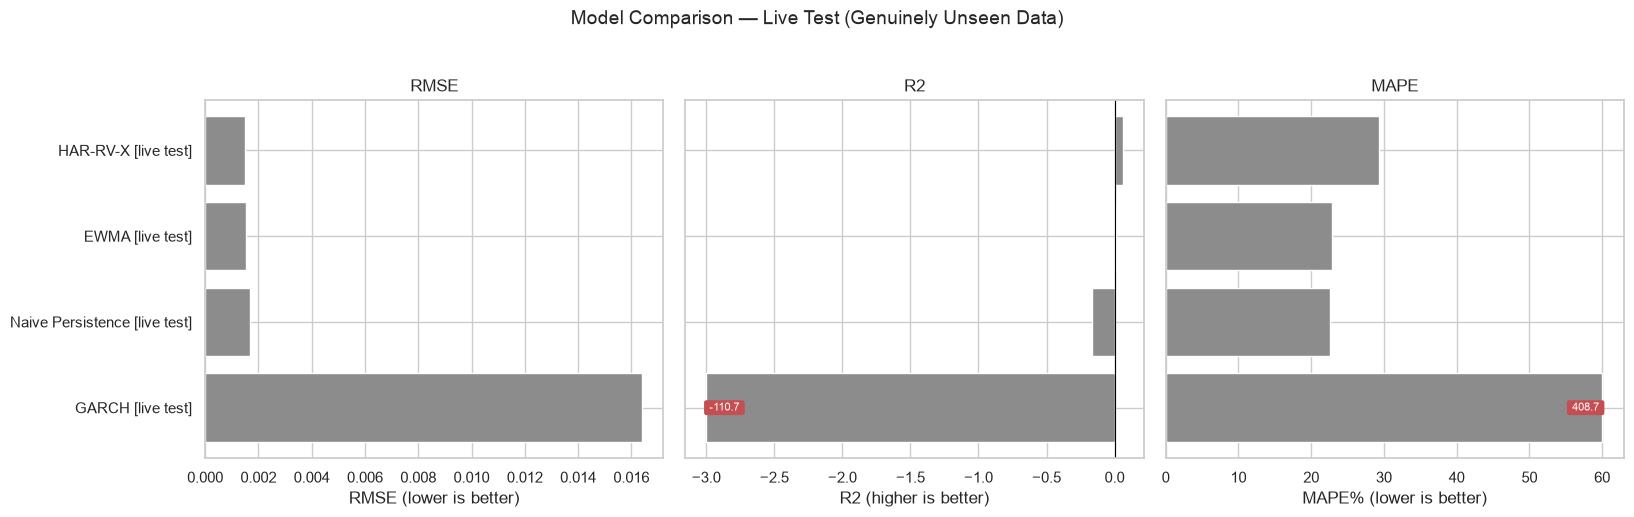

In [43]:
plot_metric_comparison(
    live_comparison_df, ['RMSE', 'R2', 'MAPE'], 'Model Comparison — Live Test (Genuinely Unseen Data)',
    clip={'R2': (-3, None), 'MAPE': (None, 60)}
)

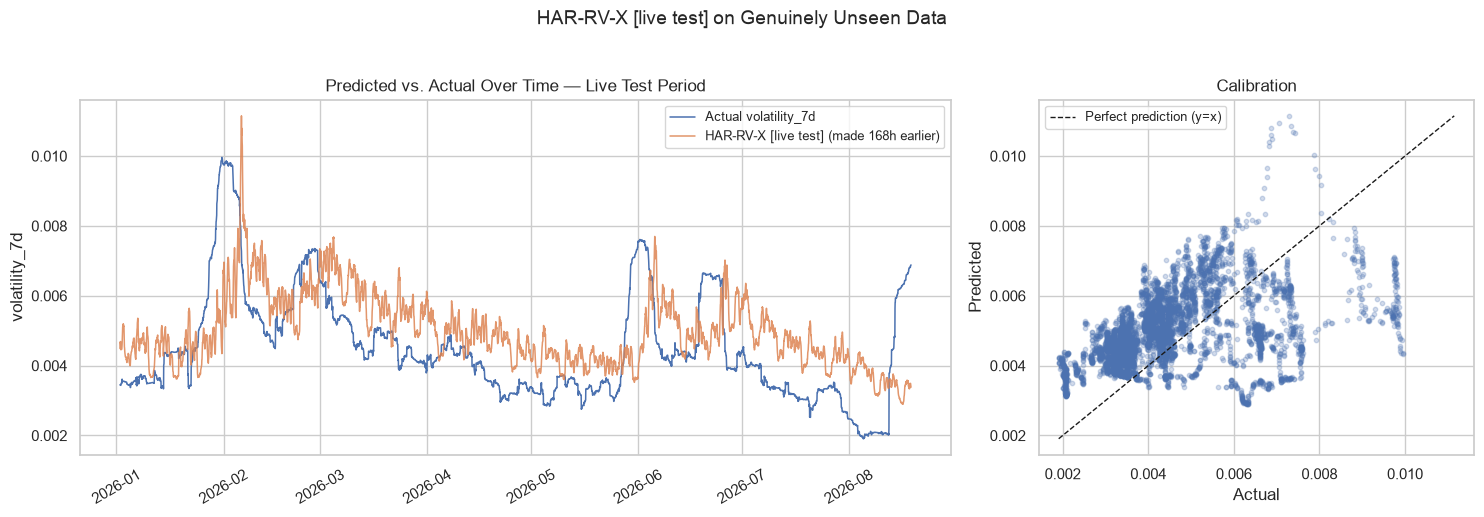

In [44]:
# Predicted vs. Actual over time, and a calibration scatter, for the best-performing
# purpose-built model on live data - the most direct visual answer to "how good is this, really?"
label_to_col = {'GARCH [live test]': 'GARCH_Pred', 'HAR-RV-X [live test]': 'HAR_RV_X_Pred',
                 'EWMA [live test]': 'EWMA_Pred'}
purpose_built = live_comparison_df[live_comparison_df['Model'].isin(label_to_col.keys())]
best_live_label = purpose_built.sort_values('RMSE').iloc[0]['Model']
best_live_col = label_to_col[best_live_label]

plot_data = live_predictions.dropna(subset=[best_live_col, 'Actual']).sort_values('Date')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(plot_data['Date'], plot_data['Actual'], label='Actual volatility_7d', color='#4C72B0', linewidth=1.1)
axes[0].plot(plot_data['Date'], plot_data[best_live_col], label=f'{best_live_label} (made {HORIZON}h earlier)',
             color='#DD8452', linewidth=1.1, alpha=0.85)
axes[0].set_ylabel('volatility_7d')
axes[0].set_title('Predicted vs. Actual Over Time — Live Test Period')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

lims = [min(plot_data['Actual'].min(), plot_data[best_live_col].min()),
        max(plot_data['Actual'].max(), plot_data[best_live_col].max())]
axes[1].scatter(plot_data['Actual'], plot_data[best_live_col], alpha=0.25, s=10, color='#4C72B0')
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction (y=x)')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Calibration')
axes[1].legend(fontsize=9)

fig.suptitle(f'{best_live_label} on Genuinely Unseen Data', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

# Conclusion

## Model Comparison
All models scored with the same `evaluate()` function, so RMSE/MAE/R² are directly comparable. Built automatically from the `results` list populated throughout — nothing here is hand-typed.

In [45]:
comparison_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison_df.style.background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r').format({'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'R2': '{:.4f}'})

,Model,RMSE,MAE,R2,MAPE
0,HAR-RV-X - Tuned,0.001418,0.001118,0.1840,24.935652
1,HAR-RV - Basic,0.001513,0.001226,0.0710,27.717535
2,EWMA (λ=0.99) - Tuned,0.001532,0.001145,0.0593,23.707450
3,Naive Persistence (baseline),0.001649,0.001210,-0.0897,24.407132
4,EWMA (λ=0.94) - Basic,0.001964,0.001460,-0.5459,30.093381
5,Holt-Winters (baseline),0.002845,0.002057,-2.2448,43.199098
6,GJR-GARCH(t) - Tuned,0.003876,0.003646,-5.0225,90.535931
7,"GARCH(1,1) - Basic",0.007293,0.007142,-20.3228,169.620850


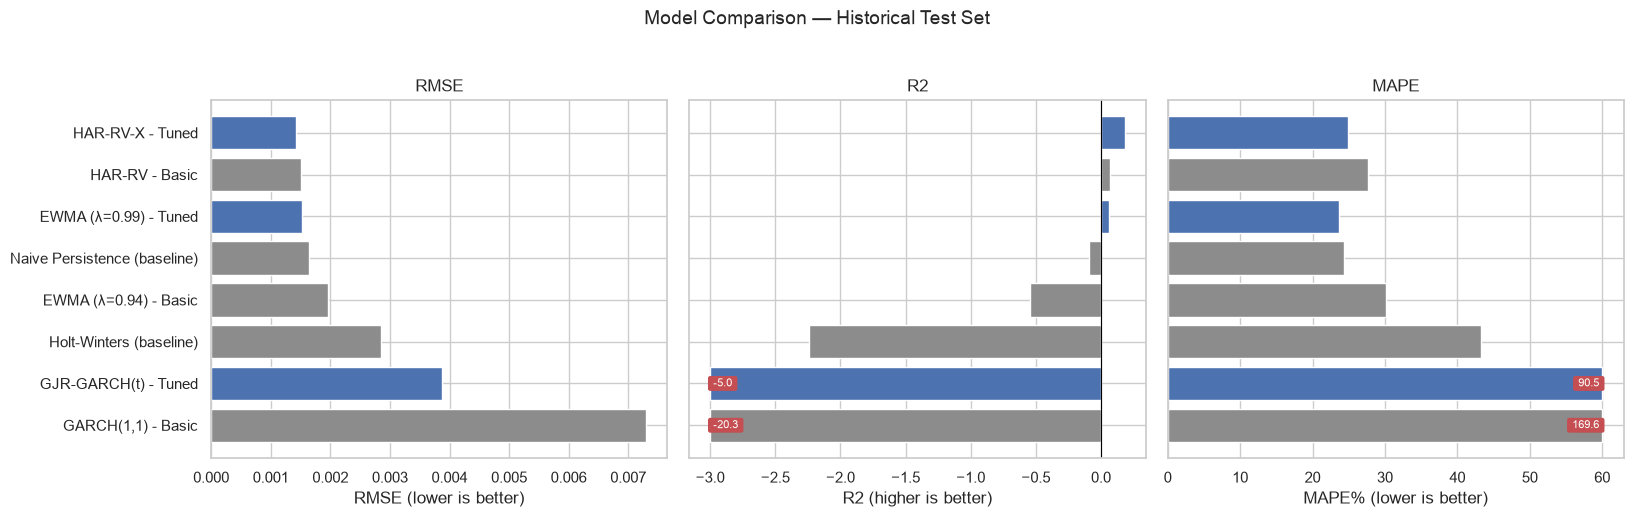

In [46]:
plot_metric_comparison(
    comparison_df, ['RMSE', 'R2', 'MAPE'], 'Model Comparison — Historical Test Set',
    clip={'R2': (-3, None), 'MAPE': (None, 60)}
)

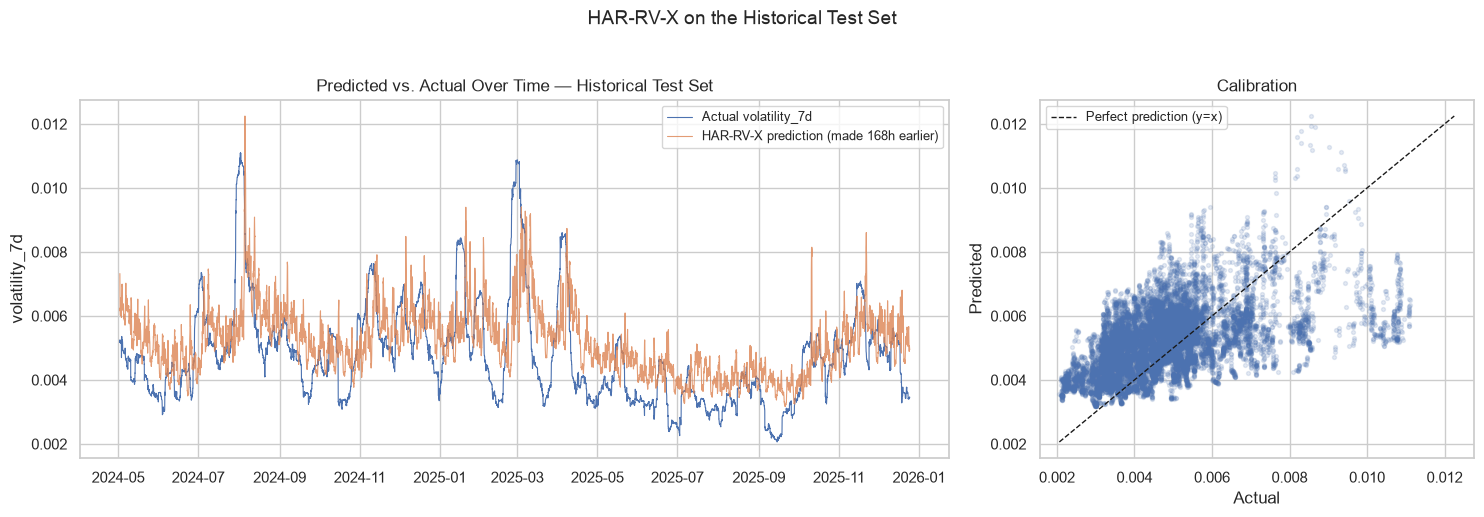

In [47]:
# Predicted vs. Actual over time, and a calibration scatter, for the historical-test-set winner
# (HAR-RV-X - it has its own slightly different date-aligned split from the other models, so its
# own dates are looked up here rather than reusing df_model['Date'].iloc[split_idx:]).
har_test_dates = df_model['Date'].loc[har_test.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(har_test_dates, har_test['target'], label='Actual volatility_7d', color='#4C72B0', linewidth=0.8)
axes[0].plot(har_test_dates, har_x_pred, label=f'HAR-RV-X prediction (made {HORIZON}h earlier)',
             color='#DD8452', linewidth=0.8, alpha=0.8)
axes[0].set_ylabel('volatility_7d')
axes[0].set_title('Predicted vs. Actual Over Time — Historical Test Set')
axes[0].legend(fontsize=9)

lims = [min(har_test['target'].min(), har_x_pred.min()), max(har_test['target'].max(), har_x_pred.max())]
axes[1].scatter(har_test['target'], har_x_pred, alpha=0.15, s=8, color='#4C72B0')
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction (y=x)')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Calibration')
axes[1].legend(fontsize=9)

fig.suptitle('HAR-RV-X on the Historical Test Set', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [48]:
best_row = comparison_df.iloc[0]
print(f"Best model (historical test set): {best_row['Model']}")
print(f"RMSE={best_row['RMSE']:.6f}  MAE={best_row['MAE']:.6f}  R2={best_row['R2']:.4f}")
print(f"\nImprovement over naive-persistence baseline: "
      f"{(1 - best_row['RMSE'] / comparison_df.loc[comparison_df['Model'].str.contains('Naive'), 'RMSE'].values[0]) * 100:.1f}% lower RMSE")
print("\nNote: this is the historical-test-set ranking. Check the Live Testing section's output "
      "(run over several days) for how the same models perform on real, never-before-seen data.")

Best model (historical test set): HAR-RV-X - Tuned
RMSE=0.001418  MAE=0.001118  R2=0.1840

Improvement over naive-persistence baseline: 14.0% lower RMSE

Note: this is the historical-test-set ranking. Check the Live Testing section's output (run over several days) for how the same models perform on real, never-before-seen data.


**Best model and justification:** *(fill in with the specific model name and numbers once the notebook is run — the cell above prints them automatically)*. Beyond raw RMSE, weigh: interpretability (HAR-RV-X's coefficients and GARCH's ω/α/β/leverage parameters, and EWMA's single λ, are all directly, theoretically meaningful — no model here is a black box), training/inference cost (all three are fast; GARCH and EWMA refit in seconds), and — uniquely enabled by this notebook's design — **how the historical-test ranking compares to the Live Testing section's real-world ranking** on the fixed, genuinely unseen live-test week. A model that wins on the historical split but underperforms live is a meaningfully different finding than one that wins on both.

## Discussion

**Business implications:** A working 7-day-ahead volatility forecast is directly usable by traders sizing positions, exchanges setting margin requirements, options desks pricing Black-Scholes σ, and portfolio managers timing entries/exits around expected turbulence. Because the target is continuous (not a high/low flag), it plugs directly into existing risk formulas.

**Limitations:**
- Volatility is inherently noisy and partly driven by information (news, regulatory action, exchange-specific events) absent from OHLCV history — there's a hard ceiling on achievable R² regardless of tuning.
- GARCH and EWMA are evaluated with parameters frozen at their training-fitted (or backtested-selected) values, using a genuine HORIZON-step-ahead rolling-origin forecast walked across the test period (never re-estimated on test data) — the standard, leakage-free way to evaluate these models out-of-sample. A production system could go further with a periodic *walk-forward refit* (re-estimating parameters every N days as new data arrives), which this notebook does not attempt.
- GARCH specifically performs poorly at a 168-hour horizon: its forecast converges toward the long-run unconditional variance well before 168 hours are up, which turns out to be a systematically poor match for `volatility_7d`'s scale (see the Model Comparison R² values and MAPE). This is a structural property of GARCH at long horizons, documented in the econometrics literature, not a defect in this implementation - HAR-RV and EWMA, which both build in longer-horizon averaging by construction, handle the 168-hour horizon far better.
- Single-asset (BTC only): no cross-asset spillover signal from other coins is used, unlike an earlier multi-coin version of this project.
- RSI, EMA spread, Bollinger width, and MACD were tested as additional HAR-RV-X regressors and did not improve performance (Robustness Checks, above) - they appear to carry momentum/direction information rather than volatility-magnitude information, which this target doesn't need.
- Ensembling HAR-RV-X with EWMA was tested with a properly cross-validated blend weight and did **not** survive validation, despite looking promising on a naive test-set peek (Robustness Checks, above) - a deliberately-included negative result and a reminder of why the blend weight can't be chosen by looking at test performance.
- The live-test window (2026-01-02 through yesterday) is fixed at the moment this notebook is run, not continuously accumulating - re-running it later will naturally score more of the already-elapsed-but-not-yet-scoreable predictions near the end of the current window, and pick up a later window if the cached CSV is deleted first.

**Future improvements:**
- News/sentiment features via an LLM-scored headline pipeline.
- A proper periodic walk-forward refit for GARCH, EWMA, and Holt-Winters, rather than parameters frozen at their training-time values.
- Extending live testing to a longer, continuously-accumulating window rather than a single fixed period.
- A genuine stacked ensemble (a small meta-model over out-of-fold predictions) rather than a fixed linear blend, which is what actually failed the robustness check above - a learned combination might still find something a fixed weight can't.

## References & Appendix

**Data source:** [CCXT](https://docs.ccxt.com/) unified exchange API, pulling hourly OHLCV data from Binance (BTC/USDT).

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`, `statsmodels`, `scikit-learn`, `arch`, `ccxt`, `joblib`.

**Key methodological references:**
- Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility.* — HAR-RV model.
- Bollerslev, T. (1986). *Generalized Autoregressive Conditional Heteroskedasticity.* — GARCH model.
- Nelson, D. (1991). *Conditional Heteroskedasticity in Asset Returns: A New Approach.* — EGARCH, capturing the leverage effect.
- Glosten, L., Jagannathan, R., Runkle, D. (1993). *On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks.* — GJR-GARCH.
- Holt, C. (1957) and Winters, P. (1960). — Exponential smoothing with trend and seasonality (Holt-Winters), used here as a seasonality-aware baseline.
- J.P. Morgan/Reuters (1996). *RiskMetrics — Technical Document* (4th ed.). — the EWMA volatility methodology and its λ=0.94 industry-standard decay factor.

**Artifacts produced by this notebook** (for reproducibility / grading):
- `btc_hourly_ohlcv.csv` — the fixed historical training dataset (as far back as Binance has, through 2026-01-01).
- `btc_hourly_live.csv` — the fixed live-test period (2026-01-02 through yesterday), fetched once.
- `live_test_predictions.csv` — every model's predictions for the live-test week, alongside the real outcomes (already known, since the window has elapsed).
- `models/` — saved GARCH spec, HAR-RV-X model, and EWMA's tuned lambda, all reloadable without retraining.